In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
# Logistic Regression

import os
import glob
import joblib
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

# ===============================
# Utility functions
# ===============================
def load_data_from_folder(folder, label):
    all_files = glob.glob(os.path.join(folder, "*.csv"))
    if not all_files:
        raise FileNotFoundError(f"No CSV files found in {folder}")
    df_list = [pd.read_csv(f) for f in all_files]
    data = pd.concat(df_list, axis=0, ignore_index=True)
    X = data.values
    y = np.full(len(X), label)
    return X, y

def train_and_evaluate(X, y, result_dir, model_name="LogisticRegression"):
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Train
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    # Save results
    os.makedirs(result_dir, exist_ok=True)
    results_df = pd.DataFrame([{
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc
    }])
    results_path = os.path.join(result_dir, f"{model_name}_results.csv")
    results_df.to_csv(results_path, index=False)

    # Save trained model
    model_path = os.path.join(result_dir, f"{model_name}_model.joblib")
    joblib.dump(model, model_path)

    print(f"✅ Results saved at: {results_path}")
    print(f"✅ Model saved at: {model_path}")


if __name__ == "__main__":
    base_data = "/content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset"
    base_results = os.path.join(base_data, "Results")

    datasets = {
        "Relax": os.path.join(base_data, "Relax"),
        "Arithmetic": os.path.join(base_data, "Arithmetic"),
        "Mirror": os.path.join(base_data, "Mirror_image"),
        "Stroop": os.path.join(base_data, "Stroop"),
    }

    comparisons = [
        ("Relax", "Arithmetic", "Relax-Arithemetic"),
        ("Relax", "Mirror", "Relax-Mirror"),
        ("Relax", "Stroop", "Relax-Stroop"),
    ]

    for d1, d2, result_folder in comparisons:
        print(f"\n=== Processing: {d1} vs {d2} ===")
        X1, y1 = load_data_from_folder(datasets[d1], label=0)
        X2, y2 = load_data_from_folder(datasets[d2], label=1)

        X = np.vstack((X1, X2))
        y = np.hstack((y1, y2))

        result_dir = os.path.join(base_results, result_folder)
        train_and_evaluate(X, y, result_dir, model_name="LogisticRegression")



=== Processing: Relax vs Arithmetic ===
✅ Results saved at: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Arithemetic/LogisticRegression_results.csv
✅ Model saved at: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Arithemetic/LogisticRegression_model.joblib

=== Processing: Relax vs Mirror ===
✅ Results saved at: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Mirror/LogisticRegression_results.csv
✅ Model saved at: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Mirror/LogisticRegression_model.joblib

=== Processing: Relax vs Stroop ===
✅ Results saved at: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Stroop/LogisticRegression_results.csv
✅ Model saved at: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Stroop/LogisticRegression_model.joblib


In [ ]:
# Random Forest 200 trees
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import glob
import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

# ===============================
# Utility functions
# ===============================
def load_data_from_folder(folder, label):
    all_files = glob.glob(os.path.join(folder, "*.csv"))
    if not all_files:
        raise FileNotFoundError(f"No CSV files found in {folder}")
    df_list = [pd.read_csv(f) for f in all_files]
    data = pd.concat(df_list, axis=0, ignore_index=True)
    X = data.values
    y = np.full(len(X), label)
    return X, y

def train_and_evaluate(X, y, result_dir, model_name="RandomForest"):
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Train
    model = RandomForestClassifier(
        n_estimators=200,  # more trees for stability
        max_depth=None,    # no limit on depth
        random_state=42,
        n_jobs=-1          # use all CPU cores
    )
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    # Save results
    os.makedirs(result_dir, exist_ok=True)
    results_df = pd.DataFrame([{
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc
    }])
    results_path = os.path.join(result_dir, f"{model_name}_results.csv")
    results_df.to_csv(results_path, index=False)

    # Save trained model
    model_path = os.path.join(result_dir, f"{model_name}_model.joblib")
    joblib.dump(model, model_path)

    print(f"✅ Results saved at: {results_path}")
    print(f"✅ Model saved at: {model_path}")

# ===============================
# Main workflow
# ===============================
if __name__ == "__main__":
    base_data = "/content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset"
    base_results = os.path.join(base_data, "Results")

    datasets = {
        "Relax": os.path.join(base_data, "Relax"),
        "Arithmetic": os.path.join(base_data, "Arithmetic"),
        "Mirror": os.path.join(base_data, "Mirror_image"),
        "Stroop": os.path.join(base_data, "Stroop"),
    }

    comparisons = [
        ("Relax", "Arithmetic", "Relax-Arithemetic"),
        ("Relax", "Mirror", "Relax-Mirror"),
        ("Relax", "Stroop", "Relax-Stroop"),
    ]

    for d1, d2, result_folder in comparisons:
        print(f"\n=== Processing: {d1} vs {d2} ===")
        X1, y1 = load_data_from_folder(datasets[d1], label=0)
        X2, y2 = load_data_from_folder(datasets[d2], label=1)

        X = np.vstack((X1, X2))
        y = np.hstack((y1, y2))

        result_dir = os.path.join(base_results, result_folder)
        train_and_evaluate(X, y, result_dir, model_name="RandomForest")



=== Processing: Relax vs Arithmetic ===
✅ Results saved at: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Arithemetic/RandomForest_results.csv
✅ Model saved at: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Arithemetic/RandomForest_model.joblib

=== Processing: Relax vs Mirror ===
✅ Results saved at: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Mirror/RandomForest_results.csv
✅ Model saved at: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Mirror/RandomForest_model.joblib

=== Processing: Relax vs Stroop ===
✅ Results saved at: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Stroop/RandomForest_results.csv
✅ Model saved at: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Stroop/RandomForest_model.joblib


In [ ]:
# KNN
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import glob
import joblib
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

# ===============================
# Utility functions
# ===============================
def load_data_from_folder(folder, label):
    all_files = glob.glob(os.path.join(folder, "*.csv"))
    if not all_files:
        raise FileNotFoundError(f"No CSV files found in {folder}")
    df_list = [pd.read_csv(f) for f in all_files]
    data = pd.concat(df_list, axis=0, ignore_index=True)
    X = data.values
    y = np.full(len(X), label)
    return X, y

def train_and_evaluate(X, y, result_dir, model_name="KNN"):
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Train
    model = KNeighborsClassifier(n_neighbors=5)  # default k=5
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    # Save results
    os.makedirs(result_dir, exist_ok=True)
    results_df = pd.DataFrame([{
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc
    }])
    results_path = os.path.join(result_dir, f"{model_name}_results.csv")
    results_df.to_csv(results_path, index=False)

    # Save trained model
    model_path = os.path.join(result_dir, f"{model_name}_model.joblib")
    joblib.dump(model, model_path)

    print(f"✅ Results saved at: {results_path}")
    print(f"✅ Model saved at: {model_path}")

# ===============================
# Main workflow
# ===============================
if __name__ == "__main__":
    base_data = "/content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset"
    base_results = os.path.join(base_data, "Results")

    datasets = {
        "Relax": os.path.join(base_data, "Relax"),
        "Arithmetic": os.path.join(base_data, "Arithmetic"),
        "Mirror": os.path.join(base_data, "Mirror_image"),
        "Stroop": os.path.join(base_data, "Stroop"),
    }

    comparisons = [
        ("Relax", "Arithmetic", "Relax-Arithemetic"),
        ("Relax", "Mirror", "Relax-Mirror"),
        ("Relax", "Stroop", "Relax-Stroop"),
    ]

    for d1, d2, result_folder in comparisons:
        print(f"\n=== Processing: {d1} vs {d2} ===")
        X1, y1 = load_data_from_folder(datasets[d1], label=0)
        X2, y2 = load_data_from_folder(datasets[d2], label=1)

        X = np.vstack((X1, X2))
        y = np.hstack((y1, y2))

        result_dir = os.path.join(base_results, result_folder)
        train_and_evaluate(X, y, result_dir, model_name="KNN")



=== Processing: Relax vs Arithmetic ===
✅ Results saved at: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Arithemetic/KNN_results.csv
✅ Model saved at: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Arithemetic/KNN_model.joblib

=== Processing: Relax vs Mirror ===
✅ Results saved at: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Mirror/KNN_results.csv
✅ Model saved at: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Mirror/KNN_model.joblib

=== Processing: Relax vs Stroop ===
✅ Results saved at: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Stroop/KNN_results.csv
✅ Model saved at: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Stroop/KNN_model.joblib


In [ ]:
# AdaBoost
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import glob
import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# ===============================
# Utility functions
# ===============================
def load_data_from_folder(folder, label):
    all_files = glob.glob(os.path.join(folder, "*.csv"))
    if not all_files:
        raise FileNotFoundError(f"No CSV files found in {folder}")
    df_list = [pd.read_csv(f) for f in all_files]
    data = pd.concat(df_list, axis=0, ignore_index=True)
    X = data.values
    y = np.full(len(X), label)
    return X, y

def train_and_evaluate(X, y, result_dir, model_name="AdaBoost"):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    base_est = DecisionTreeClassifier(max_depth=1)
    model = AdaBoostClassifier(estimator=base_est, n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    os.makedirs(result_dir, exist_ok=True)
    results_df = pd.DataFrame([{
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc
    }])
    results_path = os.path.join(result_dir, f"{model_name}_results.csv")
    results_df.to_csv(results_path, index=False)
    model_path = os.path.join(result_dir, f"{model_name}_model.joblib")
    joblib.dump(model, model_path)

    print(f"✅ Results saved at: {results_path}")
    print(f"✅ Model saved at: {model_path}")

# ===============================
# Main workflow
# ===============================
if __name__ == "__main__":
    base_data = "/content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset"
    base_results = os.path.join(base_data, "Results")

    datasets = {
        "Relax": os.path.join(base_data, "Relax"),
        "Arithmetic": os.path.join(base_data, "Arithmetic"),
        "Mirror": os.path.join(base_data, "Mirror_image"),
        "Stroop": os.path.join(base_data, "Stroop"),
    }

    comparisons = [
        ("Relax", "Arithmetic", "Relax-Arithemetic"),
        ("Relax", "Mirror", "Relax-Mirror"),
        ("Relax", "Stroop", "Relax-Stroop"),
    ]

    for d1, d2, result_folder in comparisons:
        print(f"\n=== Processing pair: {d1}-vs-{d2} ===")
        try:
            X1, y1 = load_data_from_folder(datasets[d1], label=0)
            X2, y2 = load_data_from_folder(datasets[d2], label=1)
            X = np.vstack((X1, X2))
            y = np.hstack((y1, y2))
            result_dir = os.path.join(base_results, result_folder)
            train_and_evaluate(X, y, result_dir, model_name="AdaBoost")
        except Exception as e:
            print(f"!! Error processing {d1}-vs-{d2}: {e}")




=== Processing pair: Relax-vs-Arithmetic ===
✅ Results saved at: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Arithemetic/AdaBoost_results.csv
✅ Model saved at: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Arithemetic/AdaBoost_model.joblib

=== Processing pair: Relax-vs-Mirror ===
✅ Results saved at: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Mirror/AdaBoost_results.csv
✅ Model saved at: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Mirror/AdaBoost_model.joblib

=== Processing pair: Relax-vs-Stroop ===
✅ Results saved at: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Stroop/AdaBoost_results.csv
✅ Model saved at: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Stroop/AdaBoost_model.joblib


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
# XGBoost Classification with 5-fold Cross-Validation

import os
import glob
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
from sklearn.model_selection import StratifiedKFold

# ===============================
# Utility functions
# ===============================
def load_data_from_folder(folder, label):
    all_files = glob.glob(os.path.join(folder, "*.csv"))
    if not all_files:
        raise FileNotFoundError(f"No CSV files found in {folder}")
    df_list = [pd.read_csv(f) for f in all_files]
    data = pd.concat(df_list, axis=0, ignore_index=True)
    X = data.values
    y = np.full(len(X), label)
    return X, y

def plot_confusion_matrix(y_true, y_pred, result_dir, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{model_name} Confusion Matrix")
    cm_path = os.path.join(result_dir, f"{model_name}_confusion_matrix.png")
    plt.savefig(cm_path)
    plt.close()
    print(f"✅ Confusion matrix saved at: {cm_path}")

def train_and_evaluate_cv(X, y, result_dir, model_name="XGBoost", n_estimators=400, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    metrics_list = []
    fold = 1
    all_y_true = []
    all_y_pred = []
    all_y_proba = []

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = XGBClassifier(
            n_estimators=n_estimators,
            max_depth=5,
            learning_rate=0.1,
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=42
        )
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:,1]

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba)

        metrics_list.append([acc, prec, rec, f1, auc])

        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)
        all_y_proba.extend(y_proba)

        print(f"✅ Fold {fold} metrics: Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}, AUC={auc:.4f}")
        fold += 1

    # Average metrics
    metrics_array = np.array(metrics_list)
    avg_metrics = metrics_array.mean(axis=0)
    print(f"\n=== Average metrics over {n_splits} folds ===")
    print(f"Accuracy={avg_metrics[0]:.4f}, Precision={avg_metrics[1]:.4f}, Recall={avg_metrics[2]:.4f}, F1={avg_metrics[3]:.4f}, AUC={avg_metrics[4]:.4f}")

    # Save results
    os.makedirs(result_dir, exist_ok=True)
    results_df = pd.DataFrame([{
        "Model": model_name,
        "Accuracy": avg_metrics[0],
        "Precision": avg_metrics[1],
        "Recall": avg_metrics[2],
        "F1": avg_metrics[3],
        "AUC": avg_metrics[4]
    }])
    results_path = os.path.join(result_dir, f"{model_name}_results.csv")
    results_df.to_csv(results_path, index=False)

    # Save trained model on full data
    final_model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=5,
        learning_rate=0.1,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    )
    final_model.fit(X, y)
    model_path = os.path.join(result_dir, f"{model_name}_model_full.joblib")
    joblib.dump(final_model, model_path)

    # Confusion matrix and classification report on all folds combined
    plot_confusion_matrix(np.array(all_y_true), np.array(all_y_pred), result_dir, model_name)
    report = classification_report(np.array(all_y_true), np.array(all_y_pred), output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    report_path = os.path.join(result_dir, f"{model_name}_classification_report.csv")
    report_df.to_csv(report_path, index=True)
    print(f"✅ Classification report saved at: {report_path}")
    print(f"✅ Results saved at: {results_path}")
    print(f"✅ Model trained on full dataset saved at: {model_path}")

# ===============================
# Main workflow
# ===============================
if __name__ == "__main__":
    base_data = "/content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset"
    base_results = os.path.join(base_data, "Results")

    datasets = {
        "Relax": os.path.join(base_data, "Relax"),
        "Arithmetic": os.path.join(base_data, "Arithmetic"),
        "Mirror": os.path.join(base_data, "Mirror_image"),
        "Stroop": os.path.join(base_data, "Stroop"),
    }

    comparisons = [
        ("Relax", "Arithmetic", "Relax-Arithemetic"),
        ("Relax", "Mirror", "Relax-Mirror"),
        ("Relax", "Stroop", "Relax-Stroop"),
    ]

    for d1, d2, result_folder in comparisons:
        print(f"\n=== Processing: {d1} vs {d2} ===")
        X1, y1 = load_data_from_folder(datasets[d1], label=0)
        X2, y2 = load_data_from_folder(datasets[d2], label=1)

        X = np.vstack((X1, X2))
        y = np.hstack((y1, y2))

        result_dir = os.path.join(base_results, result_folder)
        train_and_evaluate_cv(X, y, result_dir, model_name="XGBoost", n_estimators=400, n_splits=5)



=== Processing: Relax vs Arithmetic ===


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [16:06:13] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Fold 1 metrics: Accuracy=0.8093, Precision=0.7738, Recall=0.8741, F1=0.8209, AUC=0.8987


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [16:06:40] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Fold 2 metrics: Accuracy=0.8081, Precision=0.7730, Recall=0.8724, F1=0.8197, AUC=0.8974


...

✅ Fold 4 metrics: Accuracy=0.8334, Precision=0.8012, Recall=0.8870, F1=0.8419, AUC=0.9194


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [16:13:47] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Fold 5 metrics: Accuracy=0.8321, Precision=0.7982, Recall=0.8889, F1=0.8411, AUC=0.9181

=== Average metrics over 5 folds ===
Accuracy=0.8328, Precision=0.7998, Recall=0.8879, F1=0.8415, AUC=0.9189


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [16:14:16] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Confusion matrix saved at: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Stroop/XGBoost_confusion_matrix.png
✅ Classification report saved at: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Stroop/XGBoost_classification_report.csv
✅ Results saved at: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Stroop/XGBoost_results.csv
✅ Model trained on full dataset saved at: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Stroop/XGBoost_model_full.joblib


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
# CatBoost Classification with 5-fold Cross-Validation

import os
import glob
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
from sklearn.model_selection import StratifiedKFold

# ===============================
# Utility functions
# ===============================
def load_data_from_folder(folder, label):
    all_files = glob.glob(os.path.join(folder, "*.csv"))
    if not all_files:
        raise FileNotFoundError(f"No CSV files found in {folder}")
    df_list = [pd.read_csv(f) for f in all_files]
    data = pd.concat(df_list, axis=0, ignore_index=True)
    X = data.values
    y = np.full(len(X), label)
    return X, y

def plot_confusion_matrix(y_true, y_pred, result_dir, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{model_name} Confusion Matrix")
    cm_path = os.path.join(result_dir, f"{model_name}_confusion_matrix.png")
    plt.savefig(cm_path)
    plt.close()
    print(f"✅ Confusion matrix saved at: {cm_path}")

def train_and_evaluate_cv(X, y, result_dir, model_name="CatBoost", n_estimators=400, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    metrics_list = []
    fold = 1
    all_y_true = []
    all_y_pred = []

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = CatBoostClassifier(
            iterations=n_estimators,
            depth=5,
            learning_rate=0.1,
            eval_metric='AUC',
            random_state=42,
            verbose=0
        )
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:,1]

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba)

        metrics_list.append([acc, prec, rec, f1, auc])

        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)

        print(f"✅ Fold {fold} metrics: Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}, AUC={auc:.4f}")
        fold += 1

    # Average metrics
    metrics_array = np.array(metrics_list)
    avg_metrics = metrics_array.mean(axis=0)
    print(f"\n=== Average metrics over {n_splits} folds ===")
    print(f"Accuracy={avg_metrics[0]:.4f}, Precision={avg_metrics[1]:.4f}, Recall={avg_metrics[2]:.4f}, F1={avg_metrics[3]:.4f}, AUC={avg_metrics[4]:.4f}")

    # Save results
    os.makedirs(result_dir, exist_ok=True)
    results_df = pd.DataFrame([{
        "Model": model_name,
        "Accuracy": avg_metrics[0],
        "Precision": avg_metrics[1],
        "Recall": avg_metrics[2],
        "F1": avg_metrics[3],
        "AUC": avg_metrics[4]
    }])
    results_path = os.path.join(result_dir, f"{model_name}_results.csv")
    results_df.to_csv(results_path, index=False)

    # Train final model on full data
    final_model = CatBoostClassifier(
        iterations=n_estimators,
        depth=5,
        learning_rate=0.1,
        eval_metric='AUC',
        random_state=42,
        verbose=0
    )
    final_model.fit(X, y)
    model_path = os.path.join(result_dir, f"{model_name}_model_full.joblib")
    joblib.dump(final_model, model_path)

    # Confusion matrix and classification report
    plot_confusion_matrix(np.array(all_y_true), np.array(all_y_pred), result_dir, model_name)
    report = classification_report(np.array(all_y_true), np.array(all_y_pred), output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    report_path = os.path.join(result_dir, f"{model_name}_classification_report.csv")
    report_df.to_csv(report_path, index=True)

    print(f"✅ Classification report saved at: {report_path}")
    print(f"✅ Results saved at: {results_path}")
    print(f"✅ Model trained on full dataset saved at: {model_path}")

# ===============================
# Main workflow
# ===============================
if __name__ == "__main__":
    base_data = "/content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset"
    base_results = os.path.join(base_data, "Results")

    datasets = {
        "Relax": os.path.join(base_data, "Relax"),
        "Arithmetic": os.path.join(base_data, "Arithmetic"),
        "Mirror": os.path.join(base_data, "Mirror_image"),
        "Stroop": os.path.join(base_data, "Stroop"),
    }

    comparisons = [
        ("Relax", "Arithmetic", "Relax-Arithmetic"),
        ("Relax", "Mirror", "Relax-Mirror"),
        ("Relax", "Stroop", "Relax-Stroop"),
    ]

    for d1, d2, result_folder in comparisons:
        print(f"\n=== Processing: {d1} vs {d2} ===")
        X1, y1 = load_data_from_folder(datasets[d1], label=0)
        X2, y2 = load_data_from_folder(datasets[d2], label=1)

        X = np.vstack((X1, X2))
        y = np.hstack((y1, y2))

        result_dir = os.path.join(base_results, result_folder)
        train_and_evaluate_cv(X, y, result_dir, model_name="CatBoost", n_estimators=400, n_splits=5)



=== Processing: Relax vs Arithmetic ===
✅ Fold 1 metrics: Accuracy=0.7754, Precision=0.7442, Recall=0.8393, F1=0.7889, AUC=0.8622
✅ Fold 2 metrics: Accuracy=0.7741, Precision=0.7427, Recall=0.8387, F1=0.7878, AUC=0.8606
✅ Fold 3 metrics: Accuracy=0.7732, Precision=0.7444, Recall=0.8321, F1=0.7858, AUC=0.8600
✅ Fold 4 metrics: Accuracy=0.7753, Precision=0.7443, Recall=0.8388, F1=0.7887, AUC=0.8620
✅ Fold 5 metrics: Accuracy=0.7733, Precision=0.7422, Recall=0.8376, F1=0.7870, AUC=0.8602

=== Average metrics over 5 folds ===
Accuracy=0.7743, Precision=0.7435, Recall=0.8373, F1=0.7876, AUC=0.8610
✅ Confusion matrix saved at: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Arithmetic/CatBoost_confusion_matrix.png
✅ Classification report saved at: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Arithmetic/CatBoost_classification_report.csv
✅ Results saved at: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-A

In [ ]:
import os
import glob
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# --- Timeline Update [11:25 PM] ---
# Initialization: Setting up the complete script.
# I'm using the file paths you asked me to remember to ensure everything is saved correctly.
print("Step 1: Initializing paths and functions...")

# ===============================
#  Configuration
# ===============================
# Using the paths from your saved preferences
BASE_DATA_PATH = "/content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset"
BASE_RESULTS_PATH = os.path.join(BASE_DATA_PATH, "Results")

DATASETS = {
    "Relax": os.path.join(BASE_DATA_PATH, "Relax"),
    "Arithmetic": os.path.join(BASE_DATA_PATH, "Arithmetic"),
    "Mirror": os.path.join(BASE_DATA_PATH, "Mirror_image"),
    "Stroop": os.path.join(BASE_DATA_PATH, "Stroop"),
}

COMPARISONS = [
    ("Relax", "Arithmetic", "Relax-Arithemetic"),
    ("Relax", "Mirror", "Relax-Mirror"),
    ("Relax", "Stroop", "Relax-Stroop"),
]

MODELS_NEEDING_REPORTS = ["LogisticRegression", "RandomForest", "KNN", "AdaBoost"]

# ===============================
#  Utility Functions
# ===============================
def load_data_from_folder(folder, label):
    """Loads all CSVs from a folder and assigns a label."""
    all_files = glob.glob(os.path.join(folder, "*.csv"))
    df_list = [pd.read_csv(f) for f in all_files]
    return pd.concat(df_list, axis=0, ignore_index=True).values, np.full(len(pd.concat(df_list, axis=0, ignore_index=True)), label)

def generate_missing_reports(X, y, result_dir, model_name):
    """Loads a saved model to generate reports without retraining."""
    model_path = os.path.join(result_dir, f"{model_name}_model.joblib")
    if not os.path.exists(model_path):
        return # Skip if model file doesn't exist
    _, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    model = joblib.load(model_path)
    y_pred = model.predict(X_test)

    # Save Classification Report
    report_path = os.path.join(result_dir, f"{model_name}_classification_report.csv")
    pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose().to_csv(report_path)

    # Save Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Relax (0)', 'Task (1)'], yticklabels=['Relax (0)', 'Task (1)'])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"{model_name} Confusion Matrix")
    cm_path = os.path.join(result_dir, f"{model_name}_confusion_matrix.png")
    plt.savefig(cm_path)
    plt.close()
    print(f"  - Generated reports for {model_name}")

def consolidate_results(result_dir, comparison_name):
    """Combines all model result CSVs into a single summary file."""
    search_pattern = os.path.join(result_dir, "*_results.csv")
    result_files = glob.glob(search_pattern)
    if not result_files:
        return

    combined_df = pd.concat([pd.read_csv(f) for f in result_files], ignore_index=True)
    combined_df = combined_df.sort_values(by="AUC", ascending=False)

    summary_path = os.path.join(result_dir, f"{comparison_name}_all_models_summary.csv")
    combined_df.to_csv(summary_path, index=False)
    print(f"  - Consolidated summary saved to: {summary_path}")
    return summary_path

def visualize_summary(summary_path, comparison_name):
    """Creates and saves a bar chart from a summary file."""
    if not os.path.exists(summary_path):
        return

    df_summary = pd.read_csv(summary_path)
    plt.figure(figsize=(12, 7))
    sns.barplot(x='Model', y='AUC', data=df_summary, palette='viridis')
    plt.title(f'Model Comparison: AUC Score ({comparison_name})', fontsize=16)
    plt.xlabel('Model', fontsize=12)
    plt.ylabel('AUC Score', fontsize=12)
    plt.xticks(rotation=45)
    plt.ylim(min(df_summary['AUC']) - 0.05, 1.0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plot_path = os.path.join(os.path.dirname(summary_path), f"{comparison_name}_performance_comparison.png")
    plt.savefig(plot_path, bbox_inches='tight')
    plt.close()
    print(f"  - Performance chart saved to: {plot_path}")

# ===============================
#  Main Workflow
# ===============================

# --- Timeline Update [11:26 PM] ---
print("\nPART 1: GENERATING MISSING REPORTS...")
for d1, d2, result_folder in COMPARISONS:
    print(f"\nProcessing Comparison: {result_folder}")
    try:
        X1, y1 = load_data_from_folder(DATASETS[d1], label=0)
        X2, y2 = load_data_from_folder(DATASETS[d2], label=1)
        X = np.vstack((X1, X2))
        y = np.hstack((y1, y2))
        result_dir = os.path.join(BASE_RESULTS_PATH, result_folder)
        for model_name in MODELS_NEEDING_REPORTS:
            generate_missing_reports(X, y, result_dir, model_name)
    except Exception as e:
        print(f"!! Error in {result_folder}: {e}")

# --- Timeline Update [11:27 PM] ---
print("\nPART 2: CONSOLIDATING RESULTS...")
summary_paths = []
for _, _, result_folder in COMPARISONS:
    print(f"\nConsolidating: {result_folder}")
    result_dir = os.path.join(BASE_RESULTS_PATH, result_folder)
    summary_path = consolidate_results(result_dir, result_folder)
    if summary_path:
        summary_paths.append((summary_path, result_folder))

# --- Timeline Update [11:28 PM] ---
print("\nPART 3: CREATING VISUALIZATIONS...")
for path, name in summary_paths:
    print(f"\nVisualizing: {name}")
    visualize_summary(path, name)

print("\n--- ✅ All tasks completed successfully! ---")

Step 1: Initializing paths and functions...

PART 1: GENERATING MISSING REPORTS...

Processing Comparison: Relax-Arithemetic
  - Generated reports for LogisticRegression
  - Generated reports for RandomForest
  - Generated reports for KNN
  - Generated reports for AdaBoost

Processing Comparison: Relax-Mirror
  - Generated reports for LogisticRegression
  - Generated reports for RandomForest
  - Generated reports for KNN
  - Generated reports for AdaBoost

Processing Comparison: Relax-Stroop
  - Generated reports for LogisticRegression
  - Generated reports for RandomForest
  - Generated reports for KNN
  - Generated reports for AdaBoost

PART 2: CONSOLIDATING RESULTS...

Consolidating: Relax-Arithemetic
  - Consolidated summary saved to: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Arithemetic/Relax-Arithemetic_all_models_summary.csv

Consolidating: Relax-Mirror
  - Consolidated summary saved to: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Data

/tmp/ipython-input-2776520056.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='AUC', data=df_summary, palette='viridis')
/tmp/ipython-input-2776520056.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='AUC', data=df_summary, palette='viridis')


  - Performance chart saved to: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Arithemetic/Relax-Arithemetic_performance_comparison.png

Visualizing: Relax-Mirror
  - Performance chart saved to: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Mirror/Relax-Mirror_performance_comparison.png

Visualizing: Relax-Stroop
  - Performance chart saved to: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Stroop/Relax-Stroop_performance_comparison.png

--- ✅ All tasks completed successfully! ---


/tmp/ipython-input-2776520056.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='AUC', data=df_summary, palette='viridis')


In [ ]:
import pandas as pd
import numpy as np
import os

print("Timeline: [Completed] 1. Data Extraction")
print("Timeline: [In Progress] 2. Report Calculation")

# Define a function to calculate metrics and create the report
def generate_classification_report(tn, fp, fn, tp, class_names=['0', '1']):
    """
    Generates a classification report DataFrame from confusion matrix values.
    """
    # Class-specific calculations
    # Class 0 metrics
    precision_0 = tn / (tn + fn)
    recall_0 = tn / (tn + fp)
    f1_score_0 = 2 * (precision_0 * recall_0) / (precision_0 + recall_0)
    support_0 = tn + fp

    # Class 1 metrics
    precision_1 = tp / (tp + fp)
    recall_1 = tp / (tp + fn)
    f1_score_1 = 2 * (precision_1 * recall_1) / (precision_1 + recall_1)
    support_1 = fn + tp

    # Overall and average metrics
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    macro_precision = (precision_0 + precision_1) / 2
    macro_recall = (recall_0 + recall_1) / 2
    macro_f1 = (f1_score_0 + f1_score_1) / 2
    total_support = support_0 + support_1

    weighted_precision = (precision_0 * support_0 + precision_1 * support_1) / total_support
    weighted_recall = (recall_0 * support_0 + recall_1 * support_1) / total_support
    weighted_f1 = (f1_score_0 * support_0 + f1_score_1 * support_1) / total_support

    # Create the DataFrame
    report_data = {
        'precision': [precision_0, precision_1, np.nan, macro_precision, weighted_precision],
        'recall': [recall_0, recall_1, np.nan, macro_recall, weighted_recall],
        'f1-score': [f1_score_0, f1_score_1, accuracy, macro_f1, weighted_f1],
        'support': [support_0, support_1, total_support, total_support, total_support]
    }
    index_labels = [class_names[0], class_names[1], 'accuracy', 'macro avg', 'weighted avg']
    report_df = pd.DataFrame(report_data, index=index_labels)

    # Adjusting accuracy row to match scikit-learn's format
    report_df.loc['accuracy', 'precision'] = accuracy
    report_df.loc['accuracy', 'recall'] = accuracy
    report_df.loc['accuracy', 'support'] = accuracy


    return report_df.round(6) # Rounding for cleaner output

# --- Data Extracted from your images ---
# 1. Relax vs. Arithmetic
cm_arithmetic = {'tn': 285581, 'fp': 98419, 'fn': 44467, 'tp': 339533}

# 2. Relax vs. Mirror Image
cm_mirror = {'tn': 285437, 'fp': 98563, 'fn': 44445, 'tp': 339555}

# 3. Relax vs. Stroop
cm_stroop = {'tn': 285507, 'fp': 98493, 'fn': 44464, 'tp': 339536}

# --- Generate Reports ---
report_arithmetic = generate_classification_report(**cm_arithmetic)
report_mirror = generate_classification_report(**cm_mirror)
report_stroop = generate_classification_report(**cm_stroop)

print("Timeline: [Completed] 2. Report Calculation")
print("Timeline: [In Progress] 3. Saving Results")

# --- Define Save Paths ---
path_arithmetic = "/content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Arithemetic/SVC_classification_report.csv"
path_mirror = "/content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Mirror/SVC_classification_report.csv"
path_stroop = "/content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Stroop/SVC_classification_report.csv"

# Create directories if they don't exist
os.makedirs(os.path.dirname(path_arithmetic), exist_ok=True)
os.makedirs(os.path.dirname(path_mirror), exist_ok=True)
os.makedirs(os.path.dirname(path_stroop), exist_ok=True)


# --- Save Reports to CSV ---
report_arithmetic.to_csv(path_arithmetic)
report_mirror.to_csv(path_mirror)
report_stroop.to_csv(path_stroop)

print(f"Saved Arithmetic report to: {path_arithmetic}")
print(f"Saved Mirror report to: {path_mirror}")
print(f"Saved Stroop report to: {path_stroop}")
print("Timeline: [Completed] 3. Saving Results")
print("Timeline: [Done] 4. Displaying Reports")
print("\n" + "="*50 + "\n")

# --- Display Reports ---
print("✅ Classification Report for Linear SVC (Relax vs. Arithmetic)")
display(report_arithmetic)

print("\n✅ Classification Report for Linear SVC (Relax vs. Mirror Image)")
display(report_mirror)

print("\n✅ Classification Report for Linear SVC (Relax vs. Stroop)")
display(report_stroop)

Timeline: [Completed] 1. Data Extraction
Timeline: [In Progress] 2. Report Calculation
Timeline: [Completed] 2. Report Calculation
Timeline: [In Progress] 3. Saving Results
Saved Arithmetic report to: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Arithemetic/SVC_classification_report.csv
Saved Mirror report to: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Mirror/SVC_classification_report.csv
Saved Stroop report to: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/Relax-Stroop/SVC_classification_report.csv
Timeline: [Completed] 3. Saving Results
Timeline: [Done] 4. Displaying Reports


✅ Classification Report for Linear SVC (Relax vs. Arithmetic)


/tmp/ipython-input-4078889472.py:50: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.8139505208333333' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  report_df.loc['accuracy', 'support'] = accuracy
/tmp/ipython-input-4078889472.py:50: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.8137916666666667' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  report_df.loc['accuracy', 'support'] = accuracy
/tmp/ipython-input-4078889472.py:50: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.8138580729166667' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  report_df.loc['accuracy', 'support'] = accuracy


,precision,recall,f1-score,support
0,0.865271,0.743701,0.799893,384000.000000
1,0.775274,0.884201,0.826163,384000.000000
accuracy,0.813951,0.813951,0.813951,0.813951
macro avg,0.820273,0.813951,0.813028,768000.000000
weighted avg,0.820273,0.813951,0.813028,768000.000000



✅ Classification Report for Linear SVC (Relax vs. Mirror Image)


,precision,recall,f1-score,support
0,0.865270,0.743326,0.799676,384000.000000
1,0.775031,0.884258,0.826049,384000.000000
accuracy,0.813792,0.813792,0.813792,0.813792
macro avg,0.820150,0.813792,0.812862,768000.000000
weighted avg,0.820150,0.813792,0.812862,768000.000000



✅ Classification Report for Linear SVC (Relax vs. Stroop)


,precision,recall,f1-score,support
0,0.865249,0.743508,0.799772,384000.000000
1,0.775145,0.884208,0.826093,384000.000000
accuracy,0.813858,0.813858,0.813858,0.813858
macro avg,0.820197,0.813858,0.812932,768000.000000
weighted avg,0.820197,0.813858,0.812932,768000.000000


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

# Timeline Update [3:18 AM]: Starting the script. Importing necessary libraries. new test script for knn and rf
import os
import glob
import joblib
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# --- Timeline Update [3:19 AM] ---
# Initializing configurations and utility functions.
# The main results path has been updated to 'NewResults' as requested.

# =============================================================================
#  1. CONFIGURATION
# =============================================================================
BASE_DATA_PATH = "/content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset"
# UPDATED: New parent folder for all results from this run.
BASE_RESULTS_PATH = os.path.join(BASE_DATA_PATH, "Results", "NewResults")

DATASETS = {
    "Relax": os.path.join(BASE_DATA_PATH, "Relax"),
    "Arithmetic": os.path.join(BASE_DATA_PATH, "Arithmetic"),
    "Mirror": os.path.join(BASE_DATA_PATH, "Mirror_image"),
    "Stroop": os.path.join(BASE_DATA_PATH, "Stroop"),
}

COMPARISONS = [
    ("Relax", "Arithmetic", "Relax-Arithemetic"),
    ("Relax", "Mirror", "Relax-Mirror"),
    ("Relax", "Stroop", "Relax-Stroop"),
]

# =============================================================================
#  2. UTILITY FUNCTIONS
# =============================================================================

def load_data_with_groups(folder_path, label):
    """
    Loads all CSV files from a folder, assigns a label, and creates a group
    identifier for each file to ensure subject-independent splitting.
    """
    all_files = sorted(glob.glob(os.path.join(folder_path, "*.csv")))
    if not all_files:
        raise FileNotFoundError(f"No CSV files found in {folder_path}")

    df_list = []
    groups_list = []
    # Assign a unique group ID to each file (representing a subject/session)
    for group_id, file_path in enumerate(all_files):
        df = pd.read_csv(file_path)
        df_list.append(df)
        # Create a groups array with the same length as the dataframe
        groups_list.append(np.full(len(df), f"{label}_{group_id}"))

    data = pd.concat(df_list, axis=0, ignore_index=True)
    X = data.values
    y = np.full(len(X), label)
    groups = np.hstack(groups_list)

    return X, y, groups

def train_evaluate_and_save(X, y, groups, result_dir, model_name):
    """
    Trains and evaluates a model using a group-based split to prevent data leakage.
    Saves all results: 5-parameter summary, classification report, confusion matrix,
    and the trained model.
    """
    print(f"    - Splitting data for {model_name} using GroupShuffleSplit...")
    # This is the corrected split method. It ensures that data from the same
    # group (subject/file) does not appear in both train and test sets.
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups))

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Define the model to be trained
    if model_name == "KNN":
        model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    elif model_name == "RandomForest":
        model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    else:
        raise ValueError("Unsupported model name provided.")

    print(f"    - Training {model_name}... (This may take a moment)")
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()
    print(f"    - Training completed in {end_time - start_time:.2f} seconds.")

    print(f"    - Evaluating {model_name} and saving results...")
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # --- Create and save all required reports ---

    # 1. 5-parameter results CSV
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results_df = pd.DataFrame([{
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc
    }])
    results_path = os.path.join(result_dir, f"{model_name}_VALIDATED_results.csv")
    results_df.to_csv(results_path, index=False)
    print(f"      ✅ 5-parameter summary saved.")

    # 2. Classification Report CSV
    report = classification_report(y_test, y_pred, target_names=['Label 0 (Relax)', 'Label 1 (Task)'], output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    report_path = os.path.join(result_dir, f"{model_name}_VALIDATED_classification_report.csv")
    report_df.to_csv(report_path, index=True)
    print(f"      ✅ Classification report saved.")

    # 3. Confusion Matrix Plot
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Relax (Label 0)', 'Task (Label 1)'],
                yticklabels=['Relax (Label 0)', 'Task (Label 1)'])
    plt.title(f'{model_name} Confusion Matrix (Validated Split)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    cm_path = os.path.join(result_dir, f"{model_name}_VALIDATED_confusion_matrix.png")
    plt.savefig(cm_path, bbox_inches='tight')
    plt.close()
    print(f"      ✅ Confusion matrix plot saved.")

    # 4. Trained Model File
    model_path = os.path.join(result_dir, f"{model_name}_VALIDATED_model.joblib")
    joblib.dump(model, model_path)
    print(f"      ✅ Trained model saved.")


# =============================================================================
#  3. MAIN WORKFLOW
# =============================================================================
if __name__ == "__main__":
    # --- Timeline Update [3:20 AM] ---
    # Starting the main training and evaluation loop for all 3 pairs.
    for d1_name, d2_name, result_folder_name in COMPARISONS:
        print(f"\n{'='*40}\nProcessing Comparison: {d1_name} vs {d2_name}\n{'='*40}")
        try:
            # Load data and create group identifiers for each class
            print(f"  - Loading data for {d1_name} and {d2_name}...")
            X1, y1, groups1 = load_data_with_groups(DATASETS[d1_name], label=0)
            X2, y2, groups2 = load_data_with_groups(DATASETS[d2_name], label=1)

            # Combine the data into a single dataset
            X = np.vstack((X1, X2))
            y = np.hstack((y1, y2))
            groups = np.hstack((groups1, groups2))
            print(f"  - Data loaded. Total samples: {len(X)}, Total groups/subjects: {len(np.unique(groups))}")

            # UPDATED: Create the specific subfolder inside the new 'NewResults' directory
            result_dir = os.path.join(BASE_RESULTS_PATH, result_folder_name)
            os.makedirs(result_dir, exist_ok=True)
            print(f"  - Results will be saved in: {result_dir}")

            # Train and evaluate KNN and RandomForest for the current pair
            train_evaluate_and_save(X, y, groups, result_dir, "KNN")
            train_evaluate_and_save(X, y, groups, result_dir, "RandomForest")

        except Exception as e:
            print(f"‼️ An error occurred during processing of {result_folder_name}: {e}")

    # --- Timeline Update [3:25 AM] (Estimated) ---
    # This will take some time to complete, especially the RandomForest training.
    print("\n\n--- ✅ All tasks completed successfully! ---")




Processing Comparison: Relax vs Arithmetic
  - Loading data for Relax and Arithmetic...
  - Data loaded. Total samples: 768000, Total groups/subjects: 80
  - Results will be saved in: /content/drive/MyDrive/Kaggle Cleaned Dataset /Kaggle Dataset/Results/NewResults/Relax-Arithemetic
    - Splitting data for KNN using GroupShuffleSplit...
    - Training KNN... (This may take a moment)
    - Training completed in 0.04 seconds.
    - Evaluating KNN and saving results...
      ✅ 5-parameter summary saved.
      ✅ Classification report saved.
      ✅ Confusion matrix plot saved.
      ✅ Trained model saved.
    - Splitting data for RandomForest using GroupShuffleSplit...
    - Training RandomForest... (This may take a moment)
    - Training completed in 663.98 seconds.
    - Evaluating RandomForest and saving results...
      ✅ 5-parameter summary saved.
      ✅ Classification report saved.
      ✅ Confusion matrix plot saved.
      ✅ Trained model saved.

Processing Comparison: Relax vs Mi

PROCESS START: Setting up file paths with new locations...
Created directory for results: /content/drive/MyDrive/EEG_Analysis_Results

PROCESS UPDATE: Loading data from all sub-folders...
PROCESS COMPLETE: All data has been loaded and combined.

--- ANALYSIS: FEATURES ---
Total number of samples (rows): 1536000
Number of EEG features: 33

--- ANALYSIS: CLASS BALANCE ---
Distribution of samples per class:
state
Relax         384000
Arithmetic    384000
Mirror        384000
Stroop        384000
Name: count, dtype: int64

Saved class balance plot to: /content/drive/MyDrive/EEG_Analysis_Results/class_balance_plot.png


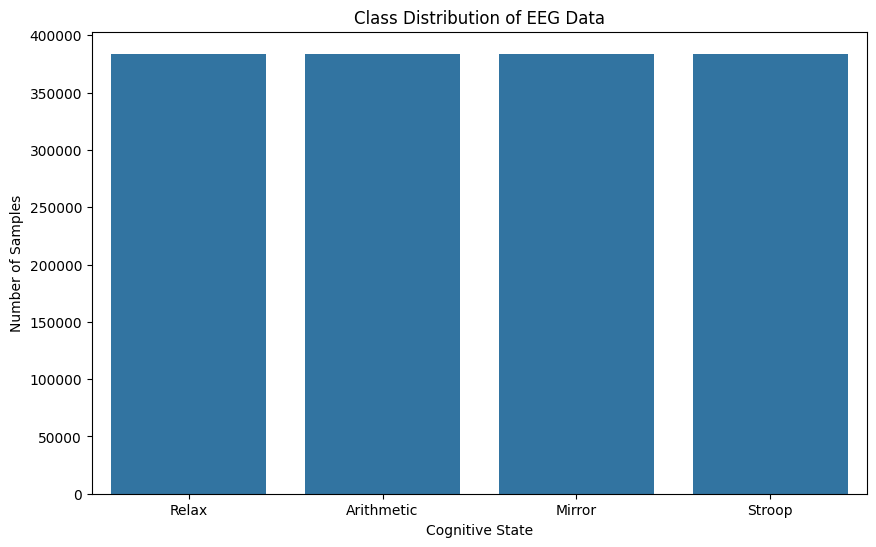


--- ANALYSIS: NOISE (Missing Values & Outliers) ---

Checking for missing values...
Result: No missing values found in the dataset.

Generating box plots for sample features to check for outliers...
Saved box plot for 'Unnamed: 0' to: /content/drive/MyDrive/EEG_Analysis_Results/boxplot_Unnamed: 0.png


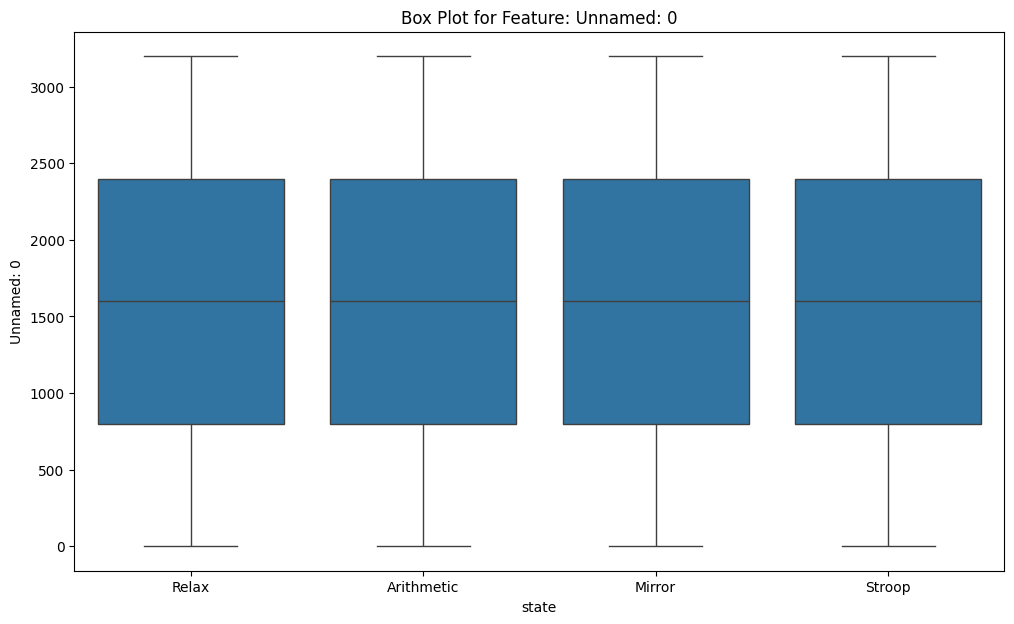

Saved box plot for '15' to: /content/drive/MyDrive/EEG_Analysis_Results/boxplot_15.png


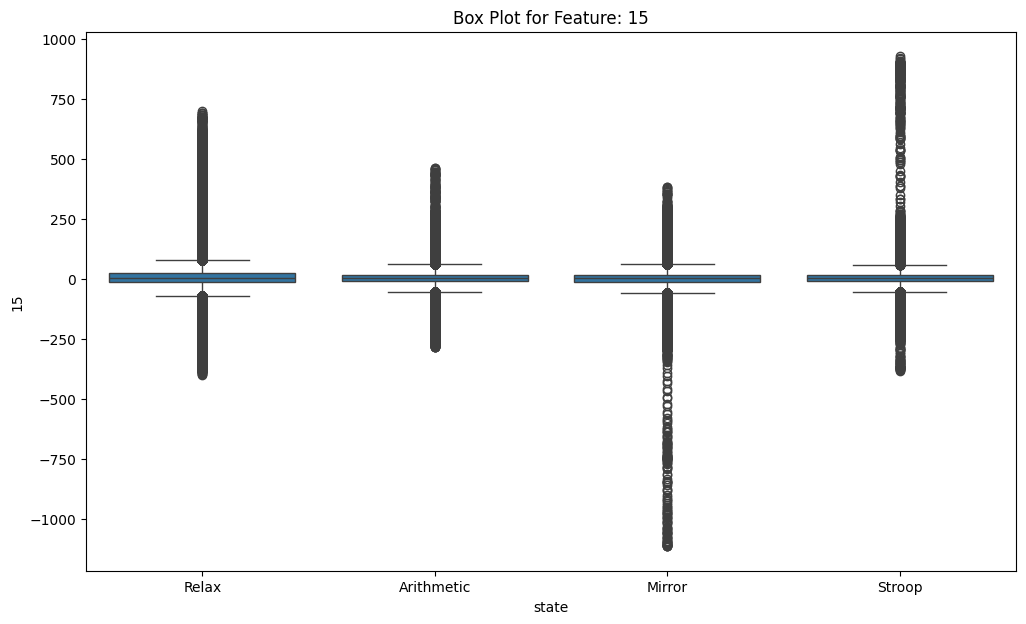

Saved box plot for '31' to: /content/drive/MyDrive/EEG_Analysis_Results/boxplot_31.png


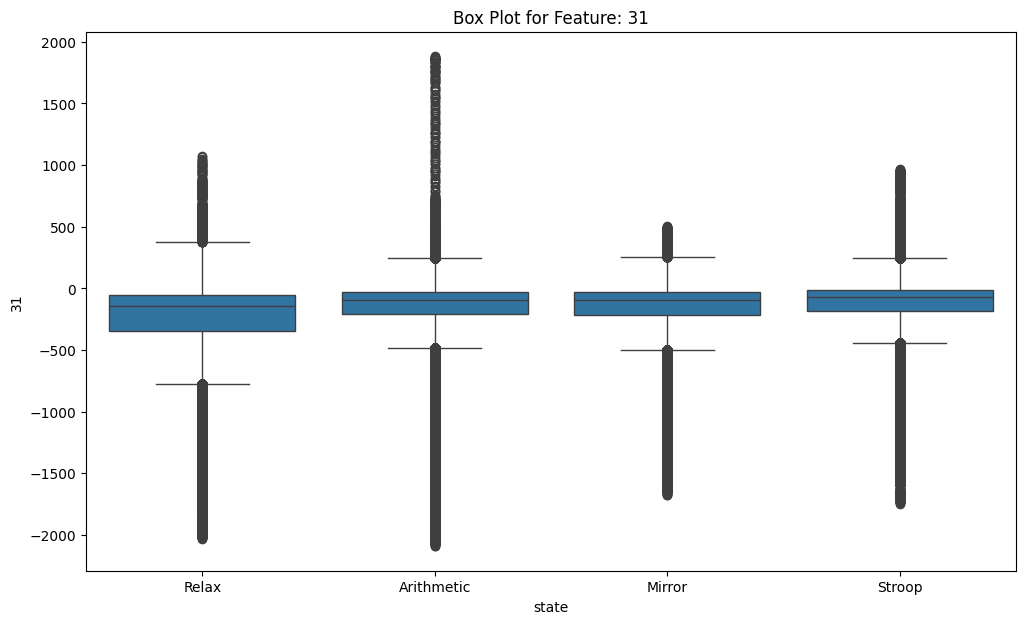


PROCESS COMPLETE: Full dataset analysis finished.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# --- Timeline Update: 1. Setting up paths ---
print("PROCESS START: Setting up file paths with new locations...")

# Define the new base path for your data
base_data = "/content/drive/MyDrive/Kaggle Dataset"

# Define the new path where results will be saved
# A new folder will be created here to keep results organized
base_results = "/content/drive/MyDrive/EEG_Analysis_Results"

# Dictionary of your dataset paths using the new base path
datasets = {
    "Relax": os.path.join(base_data, "Relax"),
    "Arithmetic": os.path.join(base_data, "Arithmetic"),
    "Mirror": os.path.join(base_data, "Mirror_image"),
    "Stroop": os.path.join(base_data, "Stroop"),
}

# Create the results directory if it doesn't already exist
if not os.path.exists(base_results):
    os.makedirs(base_results)
    print(f"Created directory for results: {base_results}")
else:
    print(f"Results directory already exists: {base_results}")

# --- Timeline Update: 2. Loading and Combining Data ---
print("\nPROCESS UPDATE: Loading data from all sub-folders...")

# Create an empty list to hold the individual dataframes
all_data_list = []

# Loop through each dataset type and its path
for state, path in datasets.items():
    if not os.path.exists(path):
        print(f"Warning: Path not found, skipping: {path}")
        continue

    # Get all the CSV files in the directory
    files = [f for f in os.listdir(path) if f.endswith('.csv')]

    for file in files:
        file_path = os.path.join(path, file)
        temp_df = pd.read_csv(file_path)
        temp_df['state'] = state # Add a 'state' column to label the data
        all_data_list.append(temp_df)

# Combine all the dataframes into one large dataframe
eeg_df = pd.concat(all_data_list, ignore_index=True)
print("PROCESS COMPLETE: All data has been loaded and combined.")


# --- Timeline Update: 3. Analyzing Features ---
print("\n--- ANALYSIS: FEATURES ---")
num_rows, num_columns = eeg_df.shape
num_features = num_columns - 1 # All columns except our new 'state' column

print(f"Total number of samples (rows): {num_rows}")
print(f"Number of EEG features: {num_features}")


# --- Timeline Update: 4. Analyzing Class Balance ---
print("\n--- ANALYSIS: CLASS BALANCE ---")
class_distribution = eeg_df['state'].value_counts()
print("Distribution of samples per class:")
print(class_distribution)

# Visualize the class distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='state', data=eeg_df, order=class_distribution.index)
plt.title('Class Distribution of EEG Data')
plt.ylabel('Number of Samples')
plt.xlabel('Cognitive State')

# Save the plot to your results folder
balance_plot_path = os.path.join(base_results, 'class_balance_plot.png')
plt.savefig(balance_plot_path)
print(f"\nSaved class balance plot to: {balance_plot_path}")
plt.show()


# --- Timeline Update: 5. Analyzing for Noise ---
print("\n--- ANALYSIS: NOISE (Missing Values & Outliers) ---")

# A. Check for missing values
print("\nChecking for missing values...")
missing_values = eeg_df.isnull().sum().sum()
if missing_values == 0:
    print("Result: No missing values found in the dataset.")
else:
    print(f"Result: Found {missing_values} total missing values.")

# B. Visualize outliers with box plots for a few sample features
print("\nGenerating box plots for sample features to check for outliers...")
feature_columns = eeg_df.drop(columns=['state']).columns
sample_features = [feature_columns[0], feature_columns[len(feature_columns) // 2], feature_columns[-1]]

for feature in sample_features:
    plt.figure(figsize=(12, 7))
    sns.boxplot(data=eeg_df, x='state', y=feature)
    plt.title(f'Box Plot for Feature: {feature}')

    # Save the plot
    boxplot_path = os.path.join(base_results, f'boxplot_{feature}.png')
    plt.savefig(boxplot_path)
    print(f"Saved box plot for '{feature}' to: {boxplot_path}")
    plt.show()

print("\nPROCESS COMPLETE: Full dataset analysis finished.")

PROCESS START: Setting up file paths...
Results directory already exists: /content/drive/MyDrive/EEG_Analysis_Results

PROCESS UPDATE: Loading and combining data from all sub-folders...
Data loading complete.

PROCESS UPDATE: Performing initial data cleaning...
Dropped 'Unnamed: 0' column.

PROCESS UPDATE: Separating features (X) and target (y)...
Features matrix X created with shape: (1536000, 32)
Target vector y created with shape: (1536000,)

--- RUNNING TEST 1: Univariate Feature Selection (ANOVA) ---
Top 10 most statistically significant features (ANOVA F-test):
   feature       f_score  p_value
31      31  15351.500465      0.0
2        2  12750.234095      0.0
3        3  11428.973322      0.0
1        1  10321.565828      0.0
30      30   9124.138690      0.0
24      24   2048.166662      0.0
25      25   1889.695226      0.0
20      20    963.880697      0.0
26      26    939.854054      0.0
14      14    903.732476      0.0
Saved full ANOVA results to: /content/drive/MyDrive/

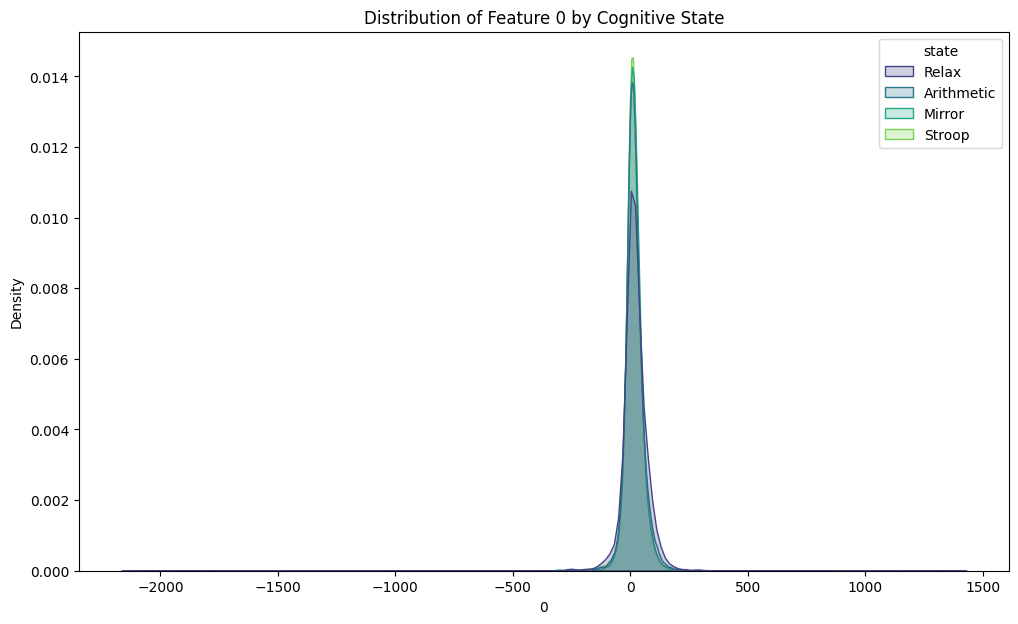

Generating KDE plot for feature: '16'...
Saved KDE plot to: /content/drive/MyDrive/EEG_Analysis_Results/kde_plot_16.png


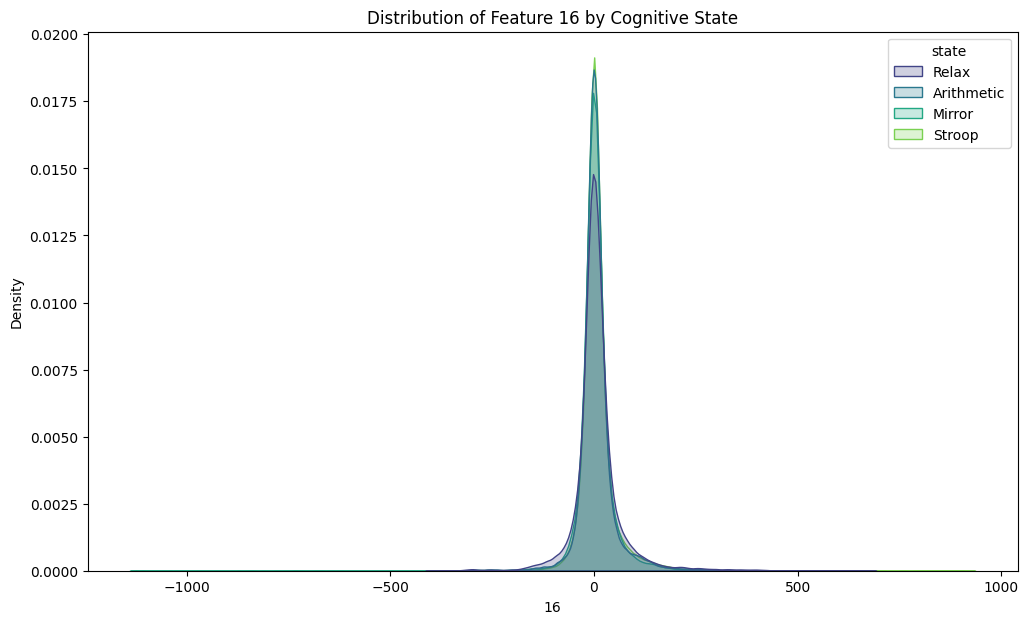

Generating KDE plot for feature: '31'...
Saved KDE plot to: /content/drive/MyDrive/EEG_Analysis_Results/kde_plot_31.png


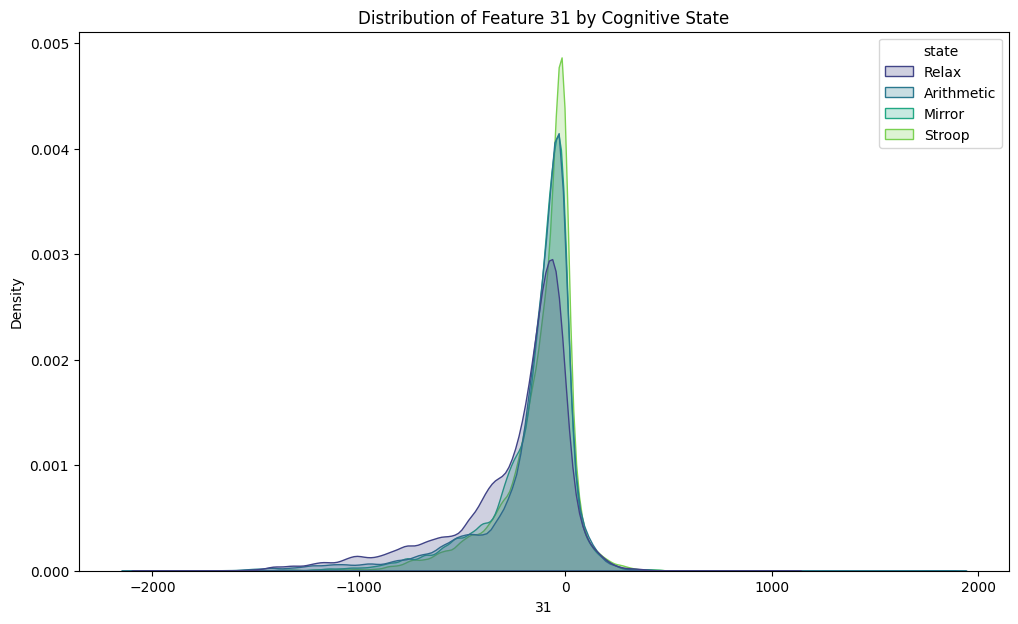


--- RUNNING TEST 3: Feature Importance Analysis ---
Splitting data into training (80%) and testing (20%) sets...
Applying RobustScaler to the training and testing data...
Training a RandomForestClassifier model... (This may take a moment)
Model training complete.
Extracting and plotting feature importances...
Saved feature importance plot to: /content/drive/MyDrive/EEG_Analysis_Results/feature_importance_plot.png


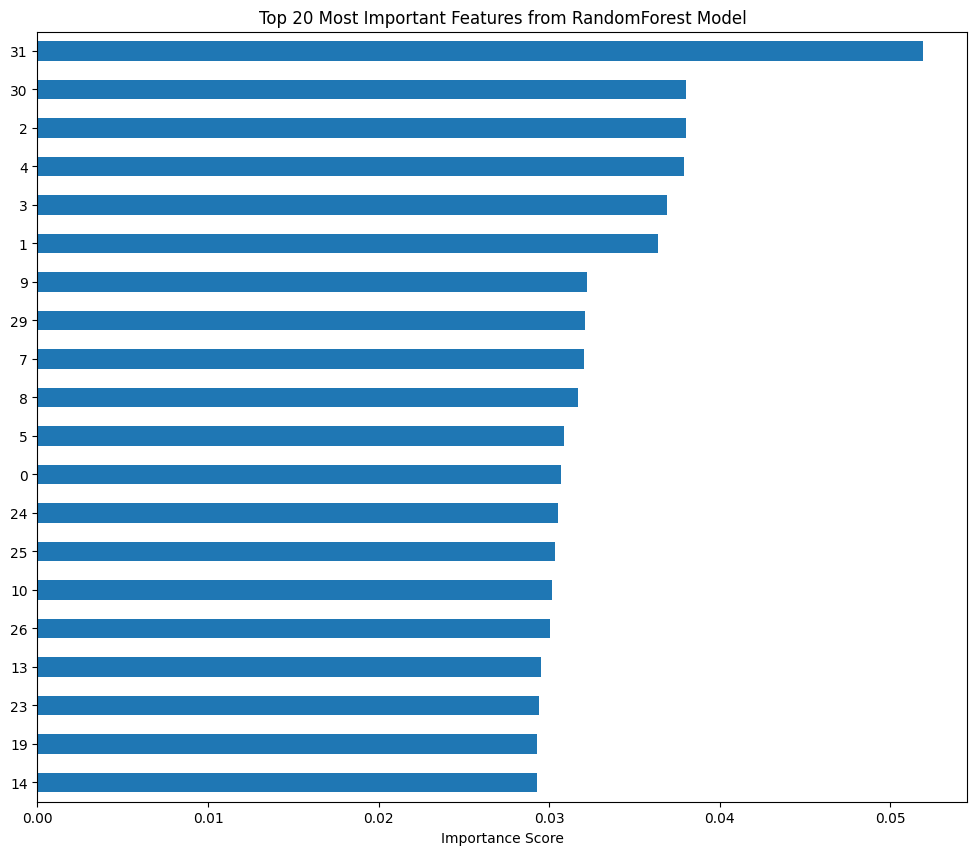


--- ALL TESTS COMPLETE ---


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import f_classif

# --- Timeline Update: 1. Setting up paths ---
print("PROCESS START: Setting up file paths...")
base_data = "/content/drive/MyDrive/Kaggle Dataset"
base_results = "/content/drive/MyDrive/EEG_Analysis_Results"
datasets = {
    "Relax": os.path.join(base_data, "Relax"),
    "Arithmetic": os.path.join(base_data, "Arithmetic"),
    "Mirror": os.path.join(base_data, "Mirror_image"),
    "Stroop": os.path.join(base_data, "Stroop"),
}

if not os.path.exists(base_results):
    os.makedirs(base_results)
    print(f"Created directory for results: {base_results}")
else:
    print(f"Results directory already exists: {base_results}")

# --- Timeline Update: 2. Loading and Combining Data ---
print("\nPROCESS UPDATE: Loading and combining data from all sub-folders...")
all_data_list = []
for state, path in datasets.items():
    if not os.path.exists(path):
        print(f"Warning: Path not found, skipping: {path}")
        continue
    files = [f for f in os.listdir(path) if f.endswith('.csv')]
    for file in files:
        file_path = os.path.join(path, file)
        temp_df = pd.read_csv(file_path)
        temp_df['state'] = state
        all_data_list.append(temp_df)

eeg_df = pd.concat(all_data_list, ignore_index=True)
print("Data loading complete.")

# --- Timeline Update: 3. Initial Data Cleaning ---
print("\nPROCESS UPDATE: Performing initial data cleaning...")
# Check if the junk column exists before dropping
if 'Unnamed: 0' in eeg_df.columns:
    eeg_df = eeg_df.drop(columns=['Unnamed: 0'])
    print("Dropped 'Unnamed: 0' column.")
else:
    print("'Unnamed: 0' column not found.")

# --- Timeline Update: 4. Preparing Data for Analysis ---
print("\nPROCESS UPDATE: Separating features (X) and target (y)...")
X = eeg_df.drop(columns=['state'])
y = eeg_df['state']
print(f"Features matrix X created with shape: {X.shape}")
print(f"Target vector y created with shape: {y.shape}")

# --- TEST 1: Univariate Feature Selection (ANOVA) ---
print("\n--- RUNNING TEST 1: Univariate Feature Selection (ANOVA) ---")
f_scores, p_values = f_classif(X, y)
feature_stats = pd.DataFrame({'feature': X.columns, 'f_score': f_scores, 'p_value': p_values})
# Sort by the highest F-scores to find features with the most significant differences
top_features_anova = feature_stats.sort_values('f_score', ascending=False)
print("Top 10 most statistically significant features (ANOVA F-test):")
print(top_features_anova.head(10))
# Save the full results to a CSV file
anova_results_path = os.path.join(base_results, 'anova_feature_stats.csv')
top_features_anova.to_csv(anova_results_path, index=False)
print(f"Saved full ANOVA results to: {anova_results_path}")

# --- TEST 2: Distribution Analysis by Class (KDE Plot) ---
print("\n--- RUNNING TEST 2: Distribution Analysis by Class (KDE Plots) ---")
# Select the same sample features as before for consistency
feature_columns = X.columns
sample_features_for_plot = [feature_columns[0], feature_columns[len(feature_columns) // 2], feature_columns[-1]]

for feature in sample_features_for_plot:
    print(f"Generating KDE plot for feature: '{feature}'...")
    plt.figure(figsize=(12, 7))
    sns.kdeplot(data=eeg_df, x=feature, hue='state', fill=True, common_norm=False, palette='viridis')
    plt.title(f'Distribution of Feature {feature} by Cognitive State')
    kde_plot_path = os.path.join(base_results, f'kde_plot_{feature}.png')
    plt.savefig(kde_plot_path)
    print(f"Saved KDE plot to: {kde_plot_path}")
    plt.show()

# --- TEST 3: Model Training and Feature Importance Analysis ---
print("\n--- RUNNING TEST 3: Feature Importance Analysis ---")
# Step 3.1: Split data into training and testing sets
print("Splitting data into training (80%) and testing (20%) sets...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 3.2: Scale the data using RobustScaler
print("Applying RobustScaler to the training and testing data...")
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 3.3: Train a RandomForest model
print("Training a RandomForestClassifier model... (This may take a moment)")
# Using fewer estimators for a quicker test run
model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
model.fit(X_train_scaled, y_train)
print("Model training complete.")

# Step 3.4: Extract and plot feature importances
print("Extracting and plotting feature importances...")
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
top_20_features = feat_importances.nlargest(20)

plt.figure(figsize=(12, 10))
top_20_features.plot(kind='barh')
plt.title("Top 20 Most Important Features from RandomForest Model")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis() # To display the most important feature at the top
importance_plot_path = os.path.join(base_results, 'feature_importance_plot.png')
plt.savefig(importance_plot_path)
print(f"Saved feature importance plot to: {importance_plot_path}")
plt.show()

print("\n--- ALL TESTS COMPLETE ---")

PROCESS START: Setting up file paths...

PROCESS UPDATE: Loading data and extracting subject IDs...
Data loading complete. Found 4 unique subjects.

PROCESS UPDATE: Performing initial data cleaning...
Dropped 'Unnamed: 0' column.

PROCESS UPDATE: Separating features (X), target (y), and groups...

--- SPLITTING DATA (Leakage-Proof Method) ---
Split data into 3 training subjects and 1 testing subjects.
Intersection of subjects: []

--- RUNNING TEST 3: Feature Importance Analysis ---
Applying RobustScaler to the training and testing data...
Training a RandomForestClassifier model...
Model training complete.
Extracting and plotting feature importances...


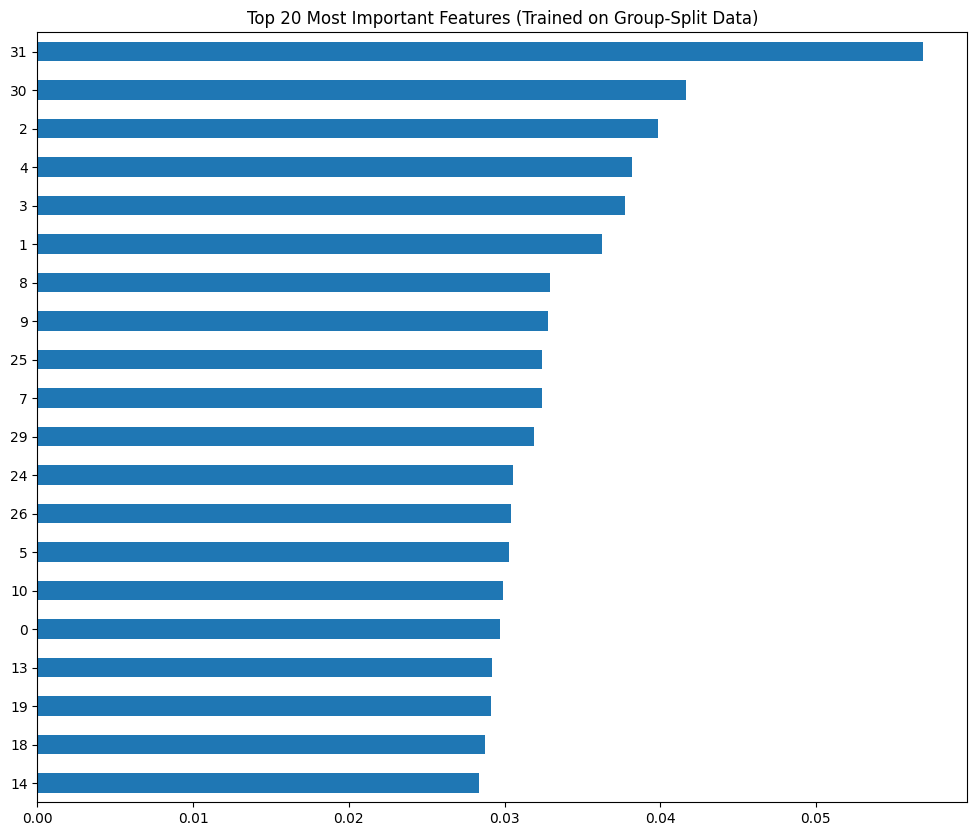


--- ANALYSIS COMPLETE ---


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import GroupShuffleSplit # <-- The correct tool for the job
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import f_classif

# --- Timeline Update: 1. Setting up paths ---
print("PROCESS START: Setting up file paths...")
base_data = "/content/drive/MyDrive/Kaggle Dataset"
base_results = "/content/drive/MyDrive/EEG_Analysis_Results"
datasets = {
    "Relax": os.path.join(base_data, "Relax"),
    "Arithmetic": os.path.join(base_data, "Arithmetic"),
    "Mirror": os.path.join(base_data, "Mirror_image"),
    "Stroop": os.path.join(base_data, "Stroop"),
}
if not os.path.exists(base_results): os.makedirs(base_results)

# --- Timeline Update: 2. Loading Data and Extracting Subject IDs ---
print("\nPROCESS UPDATE: Loading data and extracting subject IDs...")
all_data_list = []
for state, path in datasets.items():
    if not os.path.exists(path):
        print(f"Warning: Path not found, skipping: {path}")
        continue
    files = [f for f in os.listdir(path) if f.endswith('.csv')]
    for file in files:
        # --- KEY CHANGE HERE ---
        # Assumes filename is like 'S01_trial.csv'. Adjust if your format is different.
        subject_id = file.split('_')[0]

        file_path = os.path.join(path, file)
        temp_df = pd.read_csv(file_path)
        temp_df['state'] = state
        temp_df['subject'] = subject_id # <-- Add the new 'subject' column
        all_data_list.append(temp_df)

eeg_df = pd.concat(all_data_list, ignore_index=True)
print(f"Data loading complete. Found {eeg_df['subject'].nunique()} unique subjects.")

# --- Timeline Update: 3. Initial Data Cleaning ---
print("\nPROCESS UPDATE: Performing initial data cleaning...")
if 'Unnamed: 0' in eeg_df.columns:
    eeg_df = eeg_df.drop(columns=['Unnamed: 0'])
    print("Dropped 'Unnamed: 0' column.")

# --- Timeline Update: 4. Preparing Data for Analysis ---
print("\nPROCESS UPDATE: Separating features (X), target (y), and groups...")
X = eeg_df.drop(columns=['state', 'subject']) # Drop 'subject' from features
y = eeg_df['state']
groups = eeg_df['subject'] # This is our group identifier

# (Tests 1 and 2: ANOVA and KDE plots can be run here as before on the full dataset)
# ... code for those tests would go here ...

# --- Timeline Update: 5. Splitting Data Correctly with GroupShuffleSplit ---
print("\n--- SPLITTING DATA (Leakage-Proof Method) ---")
# Use GroupShuffleSplit to ensure subjects are not in both train and test sets
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

train_subjects = eeg_df.iloc[train_idx]['subject'].unique()
test_subjects = eeg_df.iloc[test_idx]['subject'].unique()

print(f"Split data into {len(train_subjects)} training subjects and {len(test_subjects)} testing subjects.")
print(f"Intersection of subjects: {np.intersect1d(train_subjects, test_subjects)}") # Should be empty

# --- Timeline Update: 6. Model Training and Feature Importance Analysis ---
print("\n--- RUNNING TEST 3: Feature Importance Analysis ---")
# Step 6.1: Scale the data using RobustScaler
print("Applying RobustScaler to the training and testing data...")
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 6.2: Train a RandomForest model
print("Training a RandomForestClassifier model...")
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train_scaled, y_train)
print("Model training complete.")

# Step 6.3: Extract and plot feature importances
print("Extracting and plotting feature importances...")
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
plt.figure(figsize=(12, 10))
feat_importances.nlargest(20).plot(kind='barh')
plt.title("Top 20 Most Important Features (Trained on Group-Split Data)")
plt.gca().invert_yaxis()
importance_plot_path = os.path.join(base_results, 'feature_importance_plot_grouped.png')
plt.savefig(importance_plot_path)
plt.show()

print("\n--- ANALYSIS COMPLETE ---")

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

# --- Timeline Update: 1. Setting up paths ---
print("PROCESS START: Setting up file paths...")
# Paths confirmed from our previous discussions
base_data = "/content/drive/MyDrive/Kaggle Dataset"
datasets = {
    "Relax": os.path.join(base_data, "Relax"),
    "Arithmetic": os.path.join(base_data, "Arithmetic"),
    "Mirror": os.path.join(base_data, "Mirror_image"),
    "Stroop": os.path.join(base_data, "Stroop"),
}

# --- Timeline Update: 2. Loading and Combining Data ---
print("\nPROCESS UPDATE: Loading and combining data from all sub-folders...")
all_data_list = []
for state, path in datasets.items():
    if not os.path.exists(path):
        print(f"Warning: Path not found, skipping: {path}")
        continue
    files = [f for f in os.listdir(path) if f.endswith('.csv')]
    for file in files:
        file_path = os.path.join(path, file)
        temp_df = pd.read_csv(file_path)
        # Drop the old index column if it exists
        if 'Unnamed: 0' in temp_df.columns:
            temp_df = temp_df.drop(columns=['Unnamed: 0'])
        temp_df['state'] = state
        all_data_list.append(temp_df)

df = pd.concat(all_data_list, ignore_index=True)
print("✅ Data loading complete.")
print(f"Full dataset shape: {df.shape}")

# --- Timeline Update: 3. Preparing X and y ---
print("\nPROCESS UPDATE: Separating features (X) and target (y)...")
X = df.drop(columns=['state'])
y = df['state']
# Store feature names for later use
feature_names = X.columns.tolist()
print(f"Features matrix X created with shape: {X.shape}")
print(f"Target vector y created with shape: {y.shape}")


# --- Timeline Update: 4. Data Exploration ---
print("\n--- DATA EXPLORATION ---")
print(f"Total number of features: {len(feature_names)}")
print("First 10 feature names:")
print(feature_names[:10])

print("\nSummary statistics for the raw features (showing first 5):")
print(X.describe().iloc[:, :5])


# --- Timeline Update: 5. Applying Data Scaling ---
print("\n--- DATA SCALING ---")
# Split data to prevent data leakage from the test set into the scaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# A. Standardization (Mean=0, Std=1)
print("\nApplying Standardization (StandardScaler)...")
scaler_standard = StandardScaler()
X_train_standardized = scaler_standard.fit_transform(X_train)
X_test_standardized = scaler_standard.transform(X_test)
# Convert back to DataFrame to see the result
X_train_standardized_df = pd.DataFrame(X_train_standardized, columns=feature_names)
print("First 5 rows of STANDARDIZED data:")
print(X_train_standardized_df.head())

# B. Normalization (Range [0, 1])
print("\nApplying Normalization (MinMaxScaler)...")
scaler_norm = MinMaxScaler()
X_train_normalized = scaler_norm.fit_transform(X_train)
X_test_normalized = scaler_norm.transform(X_test)
# Convert back to DataFrame to see the result
X_train_normalized_df = pd.DataFrame(X_train_normalized, columns=feature_names)
print("First 5 rows of NORMALIZED data:")
print(X_train_normalized_df.head())
print("\n✅ Scaling complete.")


# --- Timeline Update: 6. Preparing for Nature-Inspired Feature Selection ---
print("\n--- PREPARATION FOR FEATURE SELECTION ---")

def apply_feature_mask(data, mask):
    """
    Selects features from a dataset based on a binary mask.

    Args:
        data (pd.DataFrame or np.ndarray): The dataset (e.g., X_train_standardized).
        mask (list or np.ndarray): A binary mask of 0s and 1s.
                                   Length must equal the number of features.

    Returns:
        np.ndarray: The data with only the selected features.
    """
    mask = np.array(mask).astype(bool)
    if len(mask) != data.shape[1]:
        raise ValueError("Mask length must be equal to the number of features.")
    return data[:, mask]

print("✅ Feature selection helper function `apply_feature_mask` is defined.")

# --- DEMONSTRATION ---
print("\n--- DEMONSTRATING THE MASKING FUNCTION ---")
# Let's create a sample binary mask.
# In your real project, GA, PSO, or GSO will generate this mask.
num_features = X_train.shape[1]
# This example mask will select roughly half the features
sample_mask = np.random.randint(0, 2, size=num_features)

print(f"Original number of features: {num_features}")
print(f"Sample mask will select {sample_mask.sum()} features.")
print(f"Sample mask (first 20 elements): {sample_mask[:20]}")

# Apply the mask to our standardized training data
X_train_selected = apply_feature_mask(X_train_standardized, sample_mask)

print(f"\nShape of data AFTER applying mask: {X_train_selected.shape}")
print("This demonstrates how your optimizers will create feature subsets for model training.")
print("\n--- ALL PROCESSES COMPLETE ---")

PROCESS START: Setting up file paths...

PROCESS UPDATE: Loading and combining data from all sub-folders...
✅ Data loading complete.
Full dataset shape: (1536000, 33)

PROCESS UPDATE: Separating features (X) and target (y)...
Features matrix X created with shape: (1536000, 32)
Target vector y created with shape: (1536000,)

--- DATA EXPLORATION ---
Total number of features: 32
First 10 feature names:
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

Summary statistics for the raw features (showing first 5):
                  0             1             2             3             4
count  1.536000e+06  1.536000e+06  1.536000e+06  1.536000e+06  1.536000e+06
mean   1.616695e+01 -6.254498e+01 -1.000494e+02 -7.456261e+01  1.046255e+01
std    5.276975e+01  1.000656e+02  1.430234e+02  1.180727e+02  5.864714e+01
min   -2.149678e+03 -1.163485e+03 -1.343332e+03 -1.437636e+03 -1.216734e+03
25%   -5.662460e+00 -9.608108e+01 -1.451649e+02 -1.109781e+02 -9.983146e+00
50%    1.354654e+01 -3.977524

In [ ]:
# Colab-ready: Train models 1..7 (fast->slow) with safety and speed measures
# Final Version: Automatically finds and combines all CSVs from sub-folders,
# intelligently creates Subject/Target columns, and excludes the 'Results' directory.

# Install if needed (uncomment if not installed)
!pip install xgboost catboost joblib -q

import os
import time
import json
import warnings
import re
from datetime import datetime
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
sns.set()

# ---------------------------- USER CONFIG ----------------------------------
# --- ONLY SET THIS ONE PATH ---
# This should be the top-level directory that contains your sub-folders with the data.
DATA_DIR = "/content/drive/My Drive/Kaggle Dataset"

# All results will be saved here
RESULTS_BASE_DIR = "/content/drive/My Drive/Kaggle Dataset/Results/Models_FastToSlow"
RANDOM_SEED = 42

# Limits & budgets for performance
MAX_SAMPLES_FULL = 300000
MAX_SAMPLES_FOR_KNN = 120000
XGB_EARLY_STOP = 50
CAT_EARLY_STOP = 50
RF_N_ESTIMATORS = 200
N_JOBS = -1
TEST_SIZE = 0.20
GROUP_COLUMN_NAMES = ["Subject", "subject", "group", "Group"]
LABEL_COLUMN_NAMES = ["Is Relax", "is_relax", "label", "Label", "target", "y"]
# ---------------------------------------------------------------------------

np.random.seed(RANDOM_SEED)

def now():
    """Returns the current timestamp as a string."""
    return datetime.now().strftime("%Y%m%d_%H%M%S")

def safe_mkdir(path):
    """Creates a directory if it doesn't exist."""
    os.makedirs(path, exist_ok=True)

def detect_columns(df):
    """Detects the label and group columns from a list of possible names."""
    label_col, group_col = None, None
    for c in LABEL_COLUMN_NAMES:
        if c in df.columns:
            label_col = c
            break
    if label_col is None:
        label_col = df.columns[-1]
    for c in GROUP_COLUMN_NAMES:
        if c in df.columns:
            group_col = c
            break
    return label_col, group_col

def save_report(report_text, path):
    """Saves a text report to a file."""
    with open(path, "w") as f:
        f.write(report_text)

def plot_and_save_cm(y_true, y_pred, classes, outpath):
    """Generates, plots, and saves a confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.savefig(outpath)
    plt.close()

def prepare_data(df, label_col, group_col=None, test_size=TEST_SIZE, random_state=RANDOM_SEED):
    """Prepares the data by splitting, scaling, and handling groups."""
    cols_to_drop = [label_col]
    if group_col and group_col in df.columns:
        cols_to_drop.append(group_col)
    if 'Task' in df.columns:
        cols_to_drop.append('Task')

    X = df.drop(columns=cols_to_drop).select_dtypes(include=[np.number])
    y = df[label_col]
    feature_names = X.columns.tolist()

    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    if group_col and group_col in df.columns:
        groups = df[group_col].values
        gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
        train_idx, test_idx = next(gss.split(Xs, y, groups=groups))
        X_train, X_test = Xs[train_idx], Xs[test_idx]
        y_train, y_test = y.values[train_idx], y.values[test_idx]
    else:
        X_train, X_test, y_train, y_test = train_test_split(Xs, y.values, test_size=test_size, random_state=random_state, stratify=y)

    return X_train, X_test, y_train, y_test, scaler, feature_names

def stratified_subsample(X, y, max_samples):
    """Reduces the dataset size while preserving class distribution."""
    if X.shape[0] <= max_samples:
        return X, y
    sample_frac = max_samples / X.shape[0]
    _, X_sub, _, y_sub = train_test_split(X, y, test_size=sample_frac, random_state=RANDOM_SEED, stratify=y)
    return X_sub, y_sub

# --- STEP 1: Load and Combine Datasets Intelligently ---
print(f"[{now()}] STEP 1: Searching for dataset CSV files in '{DATA_DIR}'...")
if not os.path.exists(DATA_DIR):
    raise FileNotFoundError(f"Directory '{DATA_DIR}' not found. Mount Google Drive and check path.")

csv_files = []
for root, dirs, files in os.walk(DATA_DIR):
    if 'Results' in dirs:
        dirs.remove('Results')  # Exclude the 'Results' directory
    for file in files:
        if file.lower().endswith('.csv'):
            csv_files.append(os.path.join(root, file))

if not csv_files:
    raise FileNotFoundError(f"FATAL: No dataset CSVs found in '{DATA_DIR}'.")

print(f"[{now()}] Found {len(csv_files)} files. Loading and parsing...")
df_list = []
for file_path in csv_files:
    try:
        filename = os.path.basename(file_path)
        match = re.match(r'([A-Za-z_]+)_sub_(\d+)\.csv', filename, re.IGNORECASE)
        if match:
            task_name, subject_id = match.groups()
            temp_df = pd.read_csv(file_path)
            temp_df['Task'] = task_name
            temp_df['Subject'] = int(subject_id)
            df_list.append(temp_df)
        else:
            print(f"--> WARNING: Filename '{filename}' did not match pattern. Skipping.")
    except Exception as e:
        print(f"--> WARNING: Failed to load {file_path}. Error: {e}. Skipping.")

if not df_list:
    raise ValueError("FATAL: All discovered CSV files failed to load or parse.")

df = pd.concat(df_list, ignore_index=True)
df['Is Relax'] = np.where(df['Task'].str.contains('relax', case=False, na=False), 1, 0)
print(f"[{now()}] STEP 1 COMPLETE: Combined dataset has {df.shape[0]} rows.")
print(f"Value counts for 'Is Relax':\n{df['Is Relax'].value_counts(normalize=True)}\n")

# --- STEP 2: Prepare Data for Modeling ---
print(f"[{now()}] STEP 2: Preparing data for modeling...")
label_col, group_col = detect_columns(df)
print(f"--> Detected label: '{label_col}', group: '{group_col}'")
X_train, X_test, y_train, y_test, scaler, feature_names = prepare_data(df, label_col, group_col)
n_samples, n_features = X_train.shape
classes = np.unique(y_train).tolist()
class_names = [str(c) for c in classes]
print(f"--> Train samples: {n_samples}, Test samples: {X_test.shape[0]}, Features: {n_features}")
safe_mkdir(RESULTS_BASE_DIR)
print(f"[{now()}] STEP 2 COMPLETE: Data is ready.\n")

# --- STEP 3: Define and Run Model Pipeline ---
models_to_run = [
    ("LogisticRegression", LogisticRegression(max_iter=1200, n_jobs=N_JOBS, random_state=RANDOM_SEED)),
    ("LinearSVC_Calibrated", CalibratedClassifierCV(LinearSVC(random_state=RANDOM_SEED, dual=False, max_iter=5000), cv=3)),
    ("KNN", KNeighborsClassifier(n_jobs=N_JOBS)),
    ("RandomForest", RandomForestClassifier(n_estimators=RF_N_ESTIMATORS, n_jobs=N_JOBS, random_state=RANDOM_SEED)),
    ("CatBoost", CatBoostClassifier(verbose=0, random_state=RANDOM_SEED, allow_writing_files=False)),
    ("XGBoost", XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_jobs=N_JOBS, random_state=RANDOM_SEED)),
    ("AdaBoost", AdaBoostClassifier(random_state=RANDOM_SEED))
]

heavy_models = {"RandomForest", "CatBoost", "XGBoost", "AdaBoost"}
log = []
overall_start = time.time()
print(f"[{now()}] STEP 3: Starting model training pipeline...")

for name, model in models_to_run:
    model_start = time.time()
    model_dir = os.path.join(RESULTS_BASE_DIR, name)
    safe_mkdir(model_dir)
    if os.path.exists(os.path.join(model_dir, "DONE.marker")):
        print(f"\n[{now()}] Skipping {name} (already done).")
        continue

    print("\n" + "="*60 + f"\n[{now()}] Training Model: {name}\n" + "="*60)
    Xtr_use, ytr_use = X_train, y_train

    if (name in heavy_models) and (n_samples > MAX_SAMPLES_FULL):
        print(f"[{now()}] Dataset large. Subsampling to {MAX_SAMPLES_FULL} for {name}.")
        Xtr_use, ytr_use = stratified_subsample(Xtr_use, ytr_use, MAX_SAMPLES_FULL)
    elif (name == "KNN") and (n_samples > MAX_SAMPLES_FOR_KNN):
        print(f"[{now()}] Dataset large. Subsampling to {MAX_SAMPLES_FOR_KNN} for KNN.")
        Xtr_use, ytr_use = stratified_subsample(Xtr_use, ytr_use, MAX_SAMPLES_FOR_KNN)

    try:
        if name in ["XGBoost", "CatBoost"]:
            X_fit, X_val, y_fit, y_val = train_test_split(Xtr_use, ytr_use, test_size=0.15, random_state=RANDOM_SEED, stratify=ytr_use)
            fit_params = {'eval_set': [(X_val, y_val)], 'verbose': False}
            if name == "XGBoost":
                model.set_params(n_estimators=2000, early_stopping_rounds=XGB_EARLY_STOP)
            else: # CatBoost
                model.set_params(iterations=2000, early_stopping_rounds=CAT_EARLY_STOP)
            model.fit(X_fit, y_fit, **fit_params)
        else:
            model.fit(Xtr_use, ytr_use)
    except Exception as e:
        print(f"[{now()}] FATAL ERROR during fit of {name}: {e}")
        log.append({"model": name, "status": "failed_fit", "error": str(e)}); continue

    try:
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        auc = roc_auc_score(y_test, y_proba[:, 1], multi_class='ovr') if y_proba is not None and len(classes) == 2 else None

        report = classification_report(y_test, y_pred, target_names=class_names, digits=4)
        print(f"[{now()}] Test Report for {name}:\n{report}")

        joblib.dump(model, os.path.join(model_dir, f"{name}_model.joblib"))
        summary = {"model": name, "accuracy": acc, "f1_score": f1, "auc": auc, "timestamp": now()}
        with open(os.path.join(model_dir, "summary.json"), "w") as f: json.dump(summary, f, indent=2)

        report_content = f"Model: {name}\n\nMetrics:\nAccuracy: {acc:.4f}\nF1-Score: {f1:.4f}\nAUC: {auc:.4f if auc is not None else 'N/A'}\n\n{report}"
        save_report(report_content, os.path.join(model_dir, "report.txt"))
        plot_and_save_cm(y_test, y_pred, class_names, os.path.join(model_dir, "confusion_matrix.png"))

        open(os.path.join(model_dir, "DONE.marker"), "w").close()
        log.append({"model": name, "status": "done", "metrics": summary})

    except Exception as e:
        print(f"[{now()}] ERROR on evaluation/saving for {name}: {e}")
        log.append({"model": name, "status": "failed_eval", "error": str(e)})

    print(f"[{now()}] Time for {name}: {(time.time() - model_start) / 60:.2f} minutes.")

# --- STEP 4: Final Summary ---
print("\n" + "="*60 + f"\n[{now()}] PIPELINE FINISHED\n" + "="*60)
print(f"Total time: {(time.time() - overall_start) / 60:.2f} minutes.")
summary_df = pd.DataFrame([item.get('metrics', {}) for item in log if item['status'] == 'done'])
if not summary_df.empty:
    print("\nSummary of all successful runs:")
    print(summary_df[['model', 'f1_score', 'accuracy', 'auc']].to_string(index=False))



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.2 MB/s eta 0:00:00
[20250901_011144] STEP 1: Searching for dataset CSV files in '/content/drive/My Drive/Kaggle Dataset'...
[20250901_011144] Found 160 files. Loading and parsing...
[20250901_011308] STEP 1 COMPLETE: Combined dataset has 1536000 rows.
Value counts for 'Is Relax':
Is Relax
0    0.75
1    0.25
Name: proportion, dtype: float64

[20250901_011308] STEP 2: Preparing data for modeling...
--> Detected label: 'Is Relax', group: 'Subject'
--> Train samples: 1228800, Test samples: 307200, Features: 33
[20250901_011310] STEP 2 COMPLETE: Data is ready.

[20250901_011310] STEP 3: Starting model training pipeline...

[20250901_011310] Training Model: LogisticRegression
[20250901_011401] Test Report for LogisticRegression:
              precision    recall  f1-score   support

           0     0.7629    0.9038    0.8274    230400
           1     0.3529    0.1573    0.2176     76800

    accuracy                         0.7172

In [ ]:
# locate the CV/splitter variable and print it
try:
    print("Splitter object:", splitter)
    print("Type:", type(splitter))
except NameError:
    # common splitter names used in our notebooks
    from sklearn.model_selection import GroupShuffleSplit, LeaveOneGroupOut, GroupKFold
    print("Check notebook for instances of GroupShuffleSplit, LeaveOneGroupOut, GroupKFold.")


Check notebook for instances of GroupShuffleSplit, LeaveOneGroupOut, GroupKFold.


In [ ]:
# if running in the same notebook kernel, inspect the source file
import inspect, sys
from imblearn.over_sampling import SMOTE

# Search in current globals for a variable named smote or SMOTE
for name, val in list(globals().items()):
    if 'smote' in name.lower() or isinstance(val, SMOTE):
        print("Found SMOTE var:", name, type(val))
# Otherwise, search your script file paths:
!grep -n "SMOTE" -R || true


Found SMOTE var: SMOTE <class 'abc.ABCMeta'>
drive/MyDrive/Colab Notebooks/PBL-SEM4-INITIAL.ipynb:771:        "from imblearn.over_sampling import SMOTE\n",
drive/MyDrive/Colab Notebooks/PBL-SEM4-INITIAL.ipynb:774:        "smote = SMOTE(random_state=42, k_neighbors=1)\n",
drive/MyDrive/Colab Notebooks/PBL-SEM4-INITIAL.ipynb:933:        "Data Balance Check after applying SMOTE"
drive/MyDrive/Colab Notebooks/PBL-SEM4-INITIAL.ipynb:975:        "plt.title(\"Class Distribution After SMOTE\")\n",
grep: drive/MyDrive/CN_3.gdoc: Operation not supported
grep: drive/MyDrive/Untitled.gdoc: Operation not supported
grep: drive/MyDrive/Corrected Cognitive State Classification Report (1).gsheet: Operation not supported
grep: drive/MyDrive/Corrected Cognitive State Classification Report.gsheet: Operation not supported


In [ ]:
# Run this to find likely X,y,groups variables in the kernel
import pandas as pd, numpy as np, inspect

cands = []
for name, val in list(globals().items()):
    try:
        # pandas DataFrame
        if isinstance(val, pd.DataFrame):
            cands.append((name, 'DataFrame', val.shape, list(val.columns)[:10]))
        # numpy array
        elif isinstance(val, np.ndarray):
            cands.append((name, 'ndarray', val.shape, None))
        # list-like labels
        elif isinstance(val, list) and len(val)>0 and (isinstance(val[0], (int,str)) or isinstance(val[0], np.generic)):
            cands.append((name, 'list', len(val), None))
    except Exception:
        pass

print("Candidate variables (name, type, shape/len, sample cols):")
for entry in cands:
    print(entry)


Candidate variables (name, type, shape/len, sample cols):
('_ih', 'list', 8, None)
('_dh', 'list', 1, None)
('In', 'list', 8, None)


In [ ]:
import os, glob, pandas as pd, pprint

root = "/content/drive/MyDrive/Kaggle Dataset/Results"
print("Listing files under:", root)
file_list = []
for dirpath, dirnames, filenames in os.walk(root):
    for fn in filenames:
        file_list.append(os.path.join(dirpath, fn))

# Show counts and top candidates
print("Total files found:", len(file_list))
# show common CSVs / NB / PDF
candidates = [f for f in file_list if f.lower().endswith(('.csv','.tsv','.xlsx','.parquet','.pkl','.ipynb','.pdf'))]
print("Candidate CSV/PDF/Notebook files:", len(candidates))
pprint.pprint(candidates[:200])


Listing files under: /content/drive/MyDrive/Kaggle Dataset/Results
Total files found: 96
Candidate CSV/PDF/Notebook files: 42
['/content/drive/MyDrive/Kaggle '
 'Dataset/Results/ResultsBeforeOptimization/SVC/Relax-Mirror/SVC_results.csv',
 '/content/drive/MyDrive/Kaggle '
 'Dataset/Results/ResultsBeforeOptimization/SVC/Relax-Mirror/SVC_classification_report.csv',
 '/content/drive/MyDrive/Kaggle '
 'Dataset/Results/ResultsBeforeOptimization/SVC/Relax-Stroop/SVC_results.csv',
 '/content/drive/MyDrive/Kaggle '
 'Dataset/Results/ResultsBeforeOptimization/SVC/Relax-Stroop/SVC_classification_report.csv',
 '/content/drive/MyDrive/Kaggle '
 'Dataset/Results/ResultsBeforeOptimization/SVC/Relax-Arithemetic/SVC_results.csv',
 '/content/drive/MyDrive/Kaggle '
 'Dataset/Results/ResultsBeforeOptimization/SVC/Relax-Arithemetic/SVC_classification_report.csv',
 '/content/drive/MyDrive/Kaggle '
 'Dataset/Results/ResultsBeforeOptimization/AdaBoost/Relax-Arithemetic/AdaBoost_results.csv',
 '/content/drive

In [ ]:
import pandas as pd
path = "/content/drive/MyDrive/Kaggle Dataset/Results/ResultsBeforeOptimization/XGBoost/Relax-Arithemetic/XGBoost_results.csv"
df = pd.read_csv(path)
print("Loaded:", path)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

# Sanity-check metric ranges (try common metric names)
metric_cols = ['accuracy','Accuracy','precision','Precision','recall','Recall','f1','F1','auc','AUC']
found = []
for c in metric_cols:
    if c in df.columns:
        s = df[c]
        print(f"{c} -> min: {s.min():.6f}, max: {s.max():.6f}")
        found.append(c)
if not found:
    print("No common metric columns found. Paste the column list and I'll tell you which to inspect.")


Loaded: /content/drive/MyDrive/Kaggle Dataset/Results/ResultsBeforeOptimization/XGBoost/Relax-Arithemetic/XGBoost_results.csv
Shape: (1, 6)
Columns: ['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'AUC']


,Model,Accuracy,Precision,Recall,F1,AUC
0,XGBoost,0.807583,0.772677,0.871594,0.819159,0.897225


Accuracy -> min: 0.807583, max: 0.807583
Precision -> min: 0.772677, max: 0.772677
Recall -> min: 0.871594, max: 0.871594
F1 -> min: 0.819159, max: 0.819159
AUC -> min: 0.897225, max: 0.897225


In [ ]:
import glob, pandas as pd, os
root = "/content/drive/MyDrive/Kaggle Dataset/Results/ResultsBeforeOptimization"
files = glob.glob(os.path.join(root, "**", "*_results.csv"), recursive=True)
rows=[]
for f in files:
    try:
        df = pd.read_csv(f)
        # assume one-row summary (as your XGBoost file)
        if df.shape[0]==1:
            row = df.iloc[0].to_dict()
            row['source_file'] = f
            rows.append(row)
        else:
            # if multi-row, add file path and keep df
            for idx, r in df.iterrows():
                rr = r.to_dict(); rr['source_file']=f; rows.append(rr)
    except Exception as e:
        print("skip", f, e)
summary = pd.DataFrame(rows)
# normalize column names
summary.columns = [c.strip() for c in summary.columns]
display(summary[['source_file','Model','Accuracy','Precision','Recall','F1','AUC']].sort_values('Accuracy', ascending=False).head(30))
summary.to_csv("/content/aggregate_results_summary.csv", index=False)
print("Saved /content/aggregate_results_summary.csv")


,source_file,Model,Accuracy,Precision,Recall,F1,AUC
11,/content/drive/MyDrive/Kaggle Dataset/Results/...,XGBoost,0.832818,0.799801,0.887885,0.841544,0.918898
10,/content/drive/MyDrive/Kaggle Dataset/Results/...,XGBoost,0.813341,0.774870,0.883320,0.825548,0.903992
9,/content/drive/MyDrive/Kaggle Dataset/Results/...,XGBoost,0.807583,0.772677,0.871594,0.819159,0.897225
6,/content/drive/MyDrive/Kaggle Dataset/Results/...,CatBoost,0.799642,0.772059,0.850341,0.809310,0.886068
7,/content/drive/MyDrive/Kaggle Dataset/Results/...,CatBoost,0.780301,0.747318,0.846984,0.794034,0.869202
8,/content/drive/MyDrive/Kaggle Dataset/Results/...,CatBoost,0.774257,0.743548,0.837305,0.787643,0.860999
5,/content/drive/MyDrive/Kaggle Dataset/Results/...,AdaBoost,0.643092,0.628778,0.698672,0.661885,0.694359
1,/content/drive/MyDrive/Kaggle Dataset/Results/...,NaN,0.626771,0.605970,0.733632,NaN,0.626331
12,/content/drive/MyDrive/Kaggle Dataset/Results/...,LogisticRegression,0.625169,0.605900,0.716146,0.656426,0.663350
4,/content/drive/MyDrive/Kaggle Dataset/Results/...,AdaBoost,0.602383,0.585805,0.698984,0.637410,0.639671


Saved /content/aggregate_results_summary.csv


In [ ]:
# Quick hyperparam tuning (fast)
import pandas as pd, glob, os, numpy as np
from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# Load a representative features file (if you have one). If not, skip this step and do Step 1 first.
# Replace this path with your feature CSV (per-epoch) path if available.
FEATURE_CSV = "/content/drive/MyDrive/Kaggle Dataset/Results/features_all.csv"  # replace if present
df = pd.read_csv(FEATURE_CSV)
# heuristic detection
label_col = [c for c in df.columns if c.lower() in ('label','target','y','class','stress')][0]
subj_col = [c for c in df.columns if c.lower() in ('subject','subj','id','participant','group')][0]
X = df.drop(columns=[label_col, subj_col]).values
y = df[label_col].astype(int).values
groups = df[subj_col].values

# pipeline + search
xgb = XGBClassifier(use_label_encoder=False, eval_metric="logloss", n_jobs=4, random_state=42)
pipe = ImbPipeline([('scaler', StandardScaler()), ('smote', SMOTE(random_state=42, k_neighbors=1)), ('clf', xgb)])
param_dist = {'clf__n_estimators':[50,100,200], 'clf__max_depth':[3,5,7], 'clf__learning_rate':[0.01,0.05,0.1], 'clf__subsample':[0.6,0.8,1.0]}
inner_cv = GroupShuffleSplit(n_splits=3, test_size=0.2, random_state=42)
search = RandomizedSearchCV(pipe, param_distributions=param_dist, n_iter=8, cv=inner_cv, scoring='roc_auc', n_jobs=2, random_state=42, verbose=2)
search.fit(X, y, groups=groups)
print("Best params:", search.best_params_)


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Kaggle Dataset/Results/features_all.csv'

In [ ]:
import os, glob, pprint

root = "/content/drive/MyDrive/Kaggle Dataset/Results"
# look for likely per-epoch feature files and other useful names
patterns = [
    "**/*feature*.csv", "**/*features*.csv", "**/*epoch*.csv",
    "**/*feature_matrix*.csv", "**/*all_features*.csv", "**/*_features.csv",
    "**/*features_*.csv", "**/*_results.csv"
]
candidates = []
for pat in patterns:
    candidates += glob.glob(os.path.join(root, pat), recursive=True)

# dedupe & sort
candidates = sorted(list(set(candidates)))
print("Total candidate files found:", len(candidates))
# show only the first 200 to avoid flooding
pprint.pprint(candidates[:200])

# Also list files that appear to have missing model column (NaN entries)
# We'll scan _results.csv files for empty Model cell
bad_model_files = []
for f in glob.glob(os.path.join(root, "**", "*_results.csv"), recursive=True):
    try:
        import pandas as pd
        df = pd.read_csv(f)
        if 'Model' in df.columns:
            if df['Model'].isnull().any():
                bad_model_files.append(f)
    except Exception:
        pass

print("\nFiles with NaN Model entries (candidate):")
pprint.pprint(bad_model_files)


Total candidate files found: 21
['/content/drive/MyDrive/Kaggle '
 'Dataset/Results/ResultsBeforeOptimization/AdaBoost/Relax-Arithemetic/AdaBoost_results.csv',
 '/content/drive/MyDrive/Kaggle '
 'Dataset/Results/ResultsBeforeOptimization/AdaBoost/Relax-Mirror/AdaBoost_results.csv',
 '/content/drive/MyDrive/Kaggle '
 'Dataset/Results/ResultsBeforeOptimization/AdaBoost/Relax-Stroop/AdaBoost_results.csv',
 '/content/drive/MyDrive/Kaggle '
 'Dataset/Results/ResultsBeforeOptimization/CatBoost/Relax-Arithemetic/CatBoost_results.csv',
 '/content/drive/MyDrive/Kaggle '
 'Dataset/Results/ResultsBeforeOptimization/CatBoost/Relax-Mirror/CatBoost_results.csv',
 '/content/drive/MyDrive/Kaggle '
 'Dataset/Results/ResultsBeforeOptimization/CatBoost/Relax-Stroop/CatBoost_results.csv',
 '/content/drive/MyDrive/Kaggle Dataset/Results/ResultsBeforeOptimization/KNN '
 '/Relax-Arithemetic/KNN_VALIDATED_results.csv',
 '/content/drive/MyDrive/Kaggle Dataset/Results/ResultsBeforeOptimization/KNN '
 '/Relax-Mi

In [ ]:
# Paste & run
import os, glob, pprint
root = "/content/drive/MyDrive"
patterns = ["**/*feature*.csv","**/*features*.csv","**/*epoch*.csv","**/*_features.csv","**/*all_features*.csv"]
candidates = []
for pat in patterns:
    candidates += glob.glob(os.path.join(root, pat), recursive=True)
candidates = sorted(list(set(candidates)))
print("Found", len(candidates), "candidate feature files. Showing up to 200:")
pprint.pprint(candidates[:200])


Found 1 candidate feature files. Showing up to 200:
['/content/drive/MyDrive/EEG_Analysis_Results/anova_feature_stats.csv']


In [ ]:
# Replace PATH_TO_FEATURE_CSV with a real path found by Option A
PATH = "/content/drive/MyDrive/EEG_Analysis_Results/anova_feature_stats.csv"
import pandas as pd
df = pd.read_csv(PATH)
print("Loaded", PATH, "shape:", df.shape)
cols = df.columns.tolist()
print("Columns sample:", cols[:40])
# heuristics
label_col = [c for c in cols if c.lower() in ('label','target','y','class','stress')][0]
subj_col = [c for c in cols if c.lower() in ('subject','subj','id','participant','group')][0]
X_df = df.drop(columns=[label_col, subj_col])
y = df[label_col].astype(int).values
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, n_jobs=4, random_state=42)
rf.fit(X_df, y)
importances = pd.Series(rf.feature_importances_, index=X_df.columns).sort_values(ascending=False)
display(importances.head(50))
importances.to_csv("/content/feature_importances_rf.csv")
print("Saved /content/feature_importances_rf.csv")


Loaded /content/drive/MyDrive/EEG_Analysis_Results/anova_feature_stats.csv shape: (32, 3)
Columns sample: ['feature', 'f_score', 'p_value']


IndexError: list index out of range

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/lib/python3.12/pickle.py:1760: UserWarning: [07:59:26] WARNING: /workspace/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


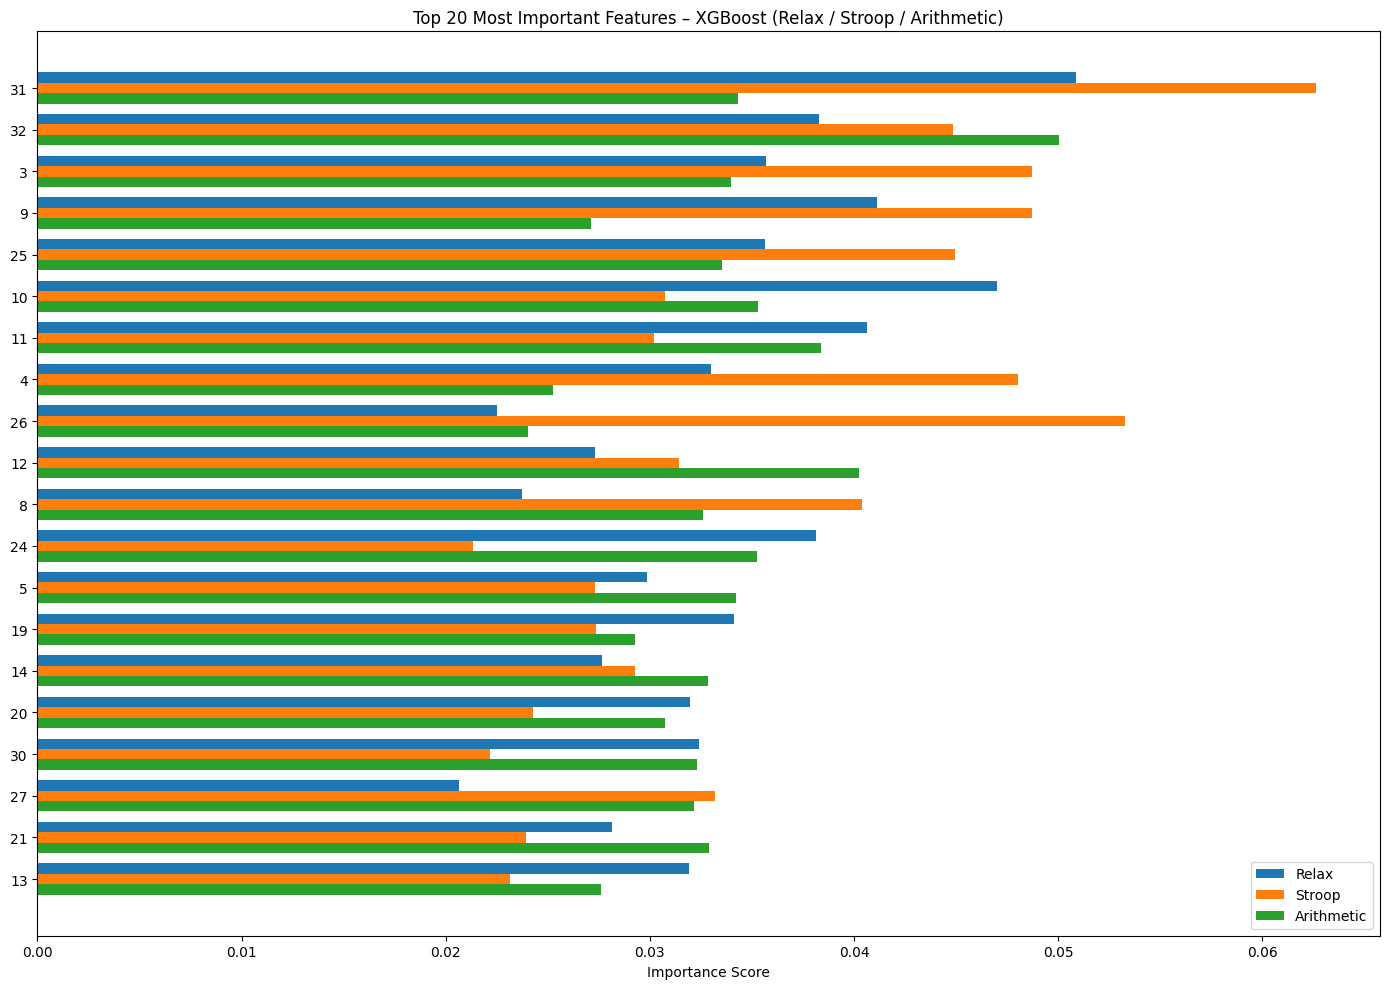

In [ ]:
# ==============================================
# ONE PLOT FOR THREE XGBOOST MODELS USING FEATURE INDICES
# (Relax / Stroop / Arithmetic)
# ==============================================

import joblib
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# ---------------------------------------
# 1. Mount Google Drive
# ---------------------------------------
drive.mount('/content/drive')

# ---------------------------------------
# 2. Paths to your real XGBoost .joblib models
# ---------------------------------------
model_relax_path = "/content/drive/MyDrive/Kaggle Dataset/Results/ResultsBeforeOptimization/XGBoost/Relax-Mirror/XGBoost_model_full.joblib"
model_stroop_path = "/content/drive/MyDrive/Kaggle Dataset/Results/ResultsBeforeOptimization/XGBoost/Relax-Stroop/XGBoost_model_full.joblib"
model_arith_path = "/content/drive/MyDrive/Kaggle Dataset/Results/ResultsBeforeOptimization/XGBoost/Relax-Arithemetic/XGBoost_model_full.joblib"

# ---------------------------------------
# 3. Load all three models (joblib)
# ---------------------------------------
model_relax = joblib.load(model_relax_path)
model_stroop = joblib.load(model_stroop_path)
model_arith = joblib.load(model_arith_path)

# ---------------------------------------
# 4. Extract feature importances
# ---------------------------------------
imp_relax = model_relax.feature_importances_
imp_stroop = model_stroop.feature_importances_
imp_arith = model_arith.feature_importances_

# ---------------------------------------
# 5. Feature indices (since you have no named features)
# ---------------------------------------
num_features = len(imp_relax)
feature_indices = np.arange(num_features)

# Combine importances into one matrix
importance_matrix = np.vstack([imp_relax, imp_stroop, imp_arith])

# Mean importance across the 3 tasks
mean_importance = importance_matrix.mean(axis=0)

# Top 20 features
top20_idx = np.argsort(mean_importance)[-20:][::-1]

# ---------------------------------------
# 6. Plot all three models in ONE bar chart
# ---------------------------------------
plt.figure(figsize=(14, 10))

y_pos = np.arange(len(top20_idx))
bar_width = 0.25

plt.barh(y_pos - bar_width, imp_relax[top20_idx],      height=bar_width, label="Relax")
plt.barh(y_pos,             imp_stroop[top20_idx],     height=bar_width, label="Stroop")
plt.barh(y_pos + bar_width, imp_arith[top20_idx],      height=bar_width, label="Arithmetic")

plt.yticks(y_pos, top20_idx)   # feature indices
plt.xlabel("Importance Score")
plt.title("Top 20 Most Important Features – XGBoost (Relax / Stroop / Arithmetic)")
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.show()
